In [2]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import read_data, nulls_nota_previa, adjust_nulls, one_hot_encoder_school, one_hot_encoder2, preprocess, semestre_to_int, normalize_train, normalize_val_test
from src.data_splitting import train_val_split_by_school, group_split_by_school, Kfold_group, random_split, temporal_split, cross_validate
from src.models import BinaryLogisticRegression, LDA, MulticlassLogisticRegression, RandomForest
from src.metrics import print_metrics, f1_score, print_metrics_multiclass, pr_curve, roc_curve, accuracy, precision, recall
from src.utils import print_confusion_matrix, print_confusion_matrix_multiclass, plot_roc_curves, plot_pr_curves, plot_cv_f1, plot_coefficient_stability, show_weights, plot_pr_curves_multiclass, plot_roc_curves_multiclass
from src.rebalance import undersample, oversample_duplicate, oversample_smote

In [3]:
# Load raw datasets and inspect a random sample for a quick overview of the data structure and content. Additionally, missing values will be checked and statistical summaries of the training data will be done.
data_train, data_test = read_data("../data/raw/rendimiento_estudiantes_dev.csv", "../data/raw/rendimiento_estudiantes_test.csv")
partition = data_train.sample(100)
display(partition)

,horas_estudio,asistencia,nota_previa,horas_sueno,participacion,horas_extracurricular,acceso_internet,distancia_escuela_km,nivel_socioeconomico,tamano_clase,escuela,semestre,rendimiento
1309,6.7,67.3,7.5,8.1,5.1,6.5,1,0.7,0.589,25,A,2023-2,Excelente
3114,7.1,52.4,4.5,8.0,2.8,0.5,1,2.6,0.418,37,D,2022-2,Bueno
2432,6.3,86.8,7.5,8.8,3.5,0.1,1,0.7,0.387,34,B,2024-1,Excelente
1819,8.0,77.7,NaN,5.8,3.5,20.0,0,5.3,0.493,25,H,2022-1,Excelente
2435,NaN,89.0,5.9,5.9,10.0,3.8,0,3.5,0.711,27,F,2023-2,Bueno
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2754,5.8,73.6,NaN,6.1,5.5,3.2,1,1.7,0.276,36,B,2022-1,Excelente
2644,7.8,30.3,8.7,5.0,4.4,1.2,1,1.9,0.407,34,B,2024-2,Bueno
1031,5.6,43.8,6.0,6.0,5.8,10.0,0,1.1,0.214,32,B,2023-1,Bueno
34,1.4,92.8,3.9,6.5,4.9,2.1,0,11.6,0.590,30,E,2022-2,Bueno


El conjunto de datos contiene valores faltantes en varias características numéricas. Estos pueden afectar el rendimiento del modelo si no se maneja adecuadamente. Por lo tanto, será necesario analizar cuidadosamente y decidir una estrategia apropiada para tratarlos durante la etapa de preprocesamiento.

In [4]:
# Starting data exploration by examining the statistical summary, data types, and missing values.

print("\nStatistical Summary of Training Data:")
display(data_train.describe())

print("\nMissing Values in Training Data:")
display(data_train.isna().sum())

print("\nMissing Values in Test Data:")
display(data_test.isna().sum())


Statistical Summary of Training Data:


,horas_estudio,asistencia,nota_previa,horas_sueno,participacion,horas_extracurricular,acceso_internet,distancia_escuela_km,nivel_socioeconomico,tamano_clase
count,4783.000000,5058.000000,4530.000000,4785.000000,4878.000000,5058.000000,5058.000000,5058.000000,4966.000000,5058.000000
mean,5.481497,62.815234,6.607307,7.032811,5.228557,3.089566,0.575722,5.678628,0.460042,31.232503
std,2.741055,19.681465,6.440261,1.300504,2.398179,3.376774,0.494282,6.948052,0.235495,6.630545
min,0.000000,0.099000,0.000000,3.000000,0.000000,0.000000,0.000000,0.300000,0.000000,15.000000
25%,3.500000,51.000000,4.600000,6.200000,3.600000,0.900000,0.000000,1.300000,0.265000,26.000000
50%,5.500000,65.100000,6.000000,7.000000,5.300000,2.100000,1.000000,3.200000,0.438000,32.000000
75%,7.400000,77.800000,7.500000,7.900000,7.000000,4.200000,1.000000,7.300000,0.651000,37.000000
max,15.400000,99.100000,100.000000,11.500000,10.000000,29.772504,1.000000,60.000000,1.000000,45.000000



Missing Values in Training Data:


horas_estudio            275
asistencia                 0
nota_previa              528
horas_sueno              273
participacion            180
horas_extracurricular      0
acceso_internet            0
distancia_escuela_km       0
nivel_socioeconomico      92
tamano_clase               0
escuela                    0
semestre                   0
rendimiento                0
dtype: int64


Missing Values in Test Data:


horas_estudio            51
asistencia                0
nota_previa               0
horas_sueno              34
participacion            26
horas_extracurricular     0
acceso_internet           0
distancia_escuela_km      0
nivel_socioeconomico     11
tamano_clase              0
escuela                   0
semestre                  0
rendimiento               0
dtype: int64

Varias características en el conjunto de entrenamiento presentan valores faltantes, particularmente nota_previa, horas_estudio, horas_sueno, nivel_socioeconomico y participacion, siendo nota_previa la que muestra la mayor proporción de datos faltantes. De manera similar, el conjunto de prueba presenta valores faltantes en las mismas características, excepto en nota_previa.

En lugar de aplicar inmediatamente técnicas de imputación, es importante primero investigar el origen de estos valores faltantes. Específicamente, analizaremos si la ausencia de datos sigue algún patrón sistemático entre las observaciones, por ejemplo, si está relacionada con escuelas específicas, semestres o rangos de otras variables. Esto puede revelar si los datos faltan al azar o si existe una razón estructural subyacente.

Además, las estadísticas sugieren posibles problemas de calidad de datos. Por ejemplo, nota_previa presenta una desviación estándar inusualmente alta y un valor máximo de 100, a pesar de que se espera que se encuentre en una escala de 0 a 10. Esta inconsistencia puede indicar la presencia de valores atípicos o datos registrados incorrectamente.

In [5]:
featuresWN = ["nota_previa", "horas_estudio", "horas_sueno", "nivel_socioeconomico", "participacion"]

for data, name in zip([data_train, data_test], ["Training", "Test"]):
    
    print(f"\n📊 Dataset: {name}")
    
    for feature in featuresWN:
        print(f"\n🔹 Feature: {feature}")

        df_escuela = data.groupby("escuela", as_index=False)[feature].agg(missing_count=lambda x: x.isna().sum())
        df_semestre = data.groupby("semestre", as_index=False)[feature].agg(missing_count=lambda x: x.isna().sum())
        
        display(df_escuela.style)
        display(df_semestre.style)


📊 Dataset: Training

🔹 Feature: nota_previa


,escuela,missing_count
0,A,59
1,B,70
2,C,49
3,D,83
4,E,60
5,F,54
6,G,97
7,H,51
8,a,0
9,b,0


,semestre,missing_count
0,2022-1,528
1,2022-2,0
2,2023-1,0
3,2023-2,0
4,2024-1,0
5,2024-2,0



🔹 Feature: horas_estudio


,escuela,missing_count
0,A,23
1,B,30
2,C,18
3,D,62
4,E,38
5,F,21
6,G,54
7,H,25
8,a,0
9,b,3


...

,escuela,missing_count
0,A,1
1,B,1
2,C,0
3,D,1
4,E,1
5,F,1
6,G,5
7,H,1
8,a,0
9,b,0


,semestre,missing_count
0,2025-1,11



🔹 Feature: participacion


,escuela,missing_count
0,A,2
1,B,5
2,C,0
3,D,5
4,E,3
5,F,3
6,G,3
7,H,5
8,a,0
9,b,0


,semestre,missing_count
0,2025-1,26


El análisis de los valores faltantes revela un patrón para la característica nota_previa. Todos los de esta variable se concentran en un único semestre (2022-1), mientras que no se observan valores faltantes en los semestres posteriores. Esto puede deberse a un problema estructural en el proceso de recolección de datos durante ese período específico. Por ejemplo, es posible que las calificaciones previas no hayan sido registradas o no estuvieran disponibles para los estudiantes en el primer semestre del conjunto de datos.

En contraste, otras características como horas_estudio, horas_sueno y participacion muestran una distribución más uniforme de valores faltantes tanto entre escuelas como entre semestres en ambos conjuntos de datos, lo que indica un patrón de ausencia más aleatorio o menos estructurado.

Se detectaron inconsistencias en la variable escuela, donde hay valores tanto en mayúsculas como en minúsculas. Estos serán estandarizados a mayúsculas para garantizar la consistencia y evitar tratar categorías idénticas como grupos diferentes. Además, los valores de nota_previa mayores a 10 serán reescalados.

In [6]:
data_train["escuela"] = data_train["escuela"].str.upper()
data_test["escuela"] = data_test["escuela"].str.upper()

for data in [data_train, data_test]:
    scaling = data["nota_previa"] > 10
    data.loc[scaling, "nota_previa"] = data.loc[scaling, "nota_previa"] / 10

Antes de imputar los datos, se debe dividir el set de entrenamiento en train y validation ya que no queremos tener data leakage al usar estadísticos que contengan datos del set de validacion.

In [7]:
train, val = train_val_split_by_school(data_train, test_size=0.2, random_state=42)

In [8]:
# Imputing missing values in 'nota_previa' for the 2022-1 semester using the median of the 2022-2 semester for each school in the train-val data.
train, val = nulls_nota_previa(train, val)

# Imputing missing values for the rest of the features using the median of the respective feature for each school, separately for train-val and test datasets.
train, val, data_test = adjust_nulls(train, val, data_test)


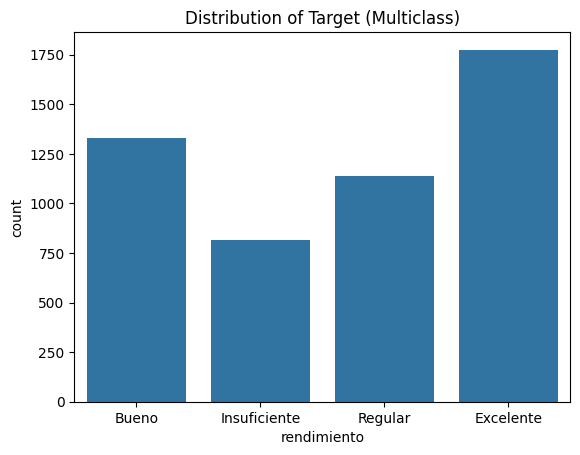

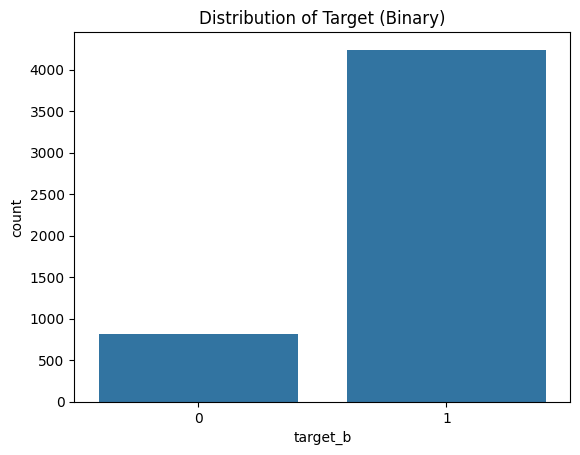

In [9]:
Ctraining = pd.concat([train, val], axis=0).reset_index(drop=True)

sns.countplot(data=Ctraining, x="rendimiento")
plt.title("Distribution of Target (Multiclass)")
plt.show()

Ctraining["target_b"] = (Ctraining["rendimiento"] != "Insuficiente").astype(int)

sns.countplot(data=Ctraining, x="target_b")
plt.title("Distribution of Target (Binary)")
plt.show()


La distribución de la variable objetivo se encuentra balanceada, con una alta concentración de observaciones en la categoría "Excelente" y una disminución progresiva en la frecuencia a medida que baja el nivel de rendimiento.

En su versión binaria, hay un desbalance evidente, ya que la cantidad de alumnos aprobados supera ampliamente a la de desaprobados (aproximadamente 4000 frente a 800).

Las variables categóricas serán transformadas a representaciones numéricas para poder ser utilizadas por los modelos de aprendizaje automático.

- rendimiento: se aplicará un mapeo a valores numéricos entre 0 y 3, respetando el orden natural de las categorías (de menor a mayor desempeño). Esto permite preservar la información ordinal de la variable.

- escuela: se utilizará codificación one-hot, ya que se trata de una variable categórica nominal sin un orden inherente. Esta transformación evita introducir relaciones artificiales entre las categorías. La transformación se hará luego del análisis para la simplicidad de los gráficos.

- semestre: se transformó a una variable numérica mediante una función que combina el año y el semestre (año * 2 + semestre), con el objetivo de preservar su estructura temporal y permitir al modelo capturar posibles tendencias en el tiempo.

array([[<Axes: title={'center': 'horas_estudio'}>,
        <Axes: title={'center': 'asistencia'}>,
        <Axes: title={'center': 'nota_previa'}>],
       [<Axes: title={'center': 'horas_sueno'}>,
        <Axes: title={'center': 'participacion'}>,
        <Axes: title={'center': 'horas_extracurricular'}>],
       [<Axes: title={'center': 'acceso_internet'}>,
        <Axes: title={'center': 'distancia_escuela_km'}>,
        <Axes: title={'center': 'nivel_socioeconomico'}>],
       [<Axes: title={'center': 'tamano_clase'}>,
        <Axes: title={'center': 'semestre'}>,
        <Axes: title={'center': 'rendimiento'}>]], dtype=object)

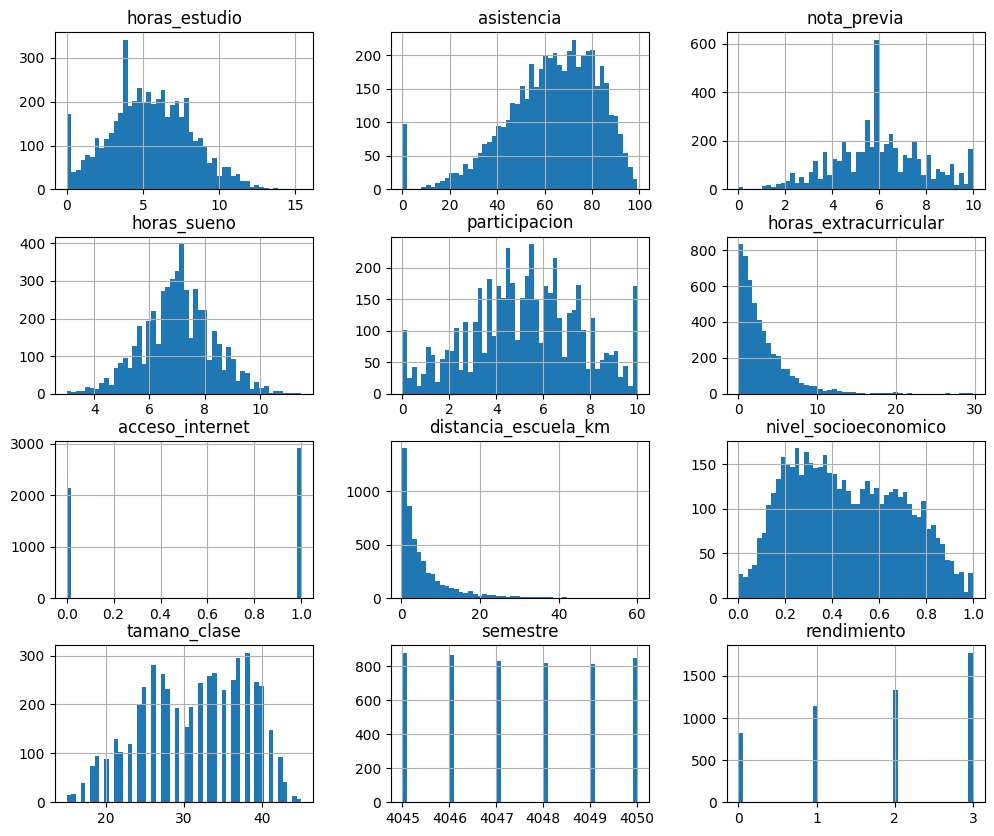

In [10]:
notes = {
    "Insuficiente": 0,
    "Regular": 1,
    "Bueno": 2,
    "Excelente": 3
}

for data in [train, val, data_test]:
    data["semestre"] = data["semestre"].apply(semestre_to_int)
    data["rendimiento"] = data["rendimiento"].map(notes)

data_total = pd.concat([train, val], axis=0).reset_index(drop=True)
data_total.hist(figsize=(12, 10), bins=50)

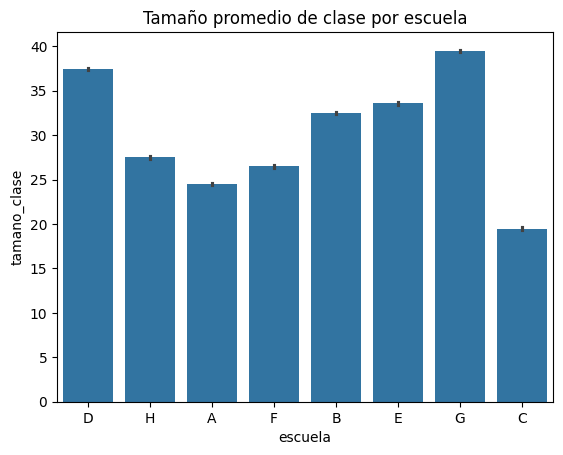

In [11]:
sns.barplot(data=data_total, x="escuela", y="tamano_clase")
plt.title("Tamaño promedio de clase por escuela")
plt.show()

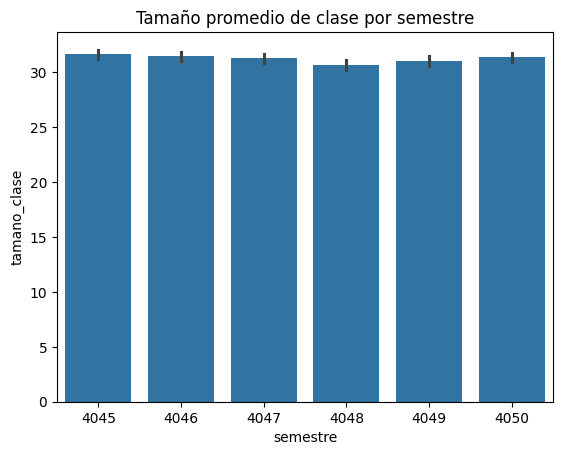

In [12]:
sns.barplot(data=data_total, x="semestre", y="tamano_clase")
plt.title("Tamaño promedio de clase por semestre")
plt.show()

El análisis de las distribuciones muestra que algunas variables como horas_estudio, horas_sueno y asistencia presentan formas aproximadamente normales, concentrándose en valores intermedios. En contraste, variables como horas_extracurricular y distancia_escuela_km presentan un fuerte sesgo hacia la derecha, con presencia de valores extremos. Otras variables, como tamano_clase, presentan distribuciones discretas debido a la naturaleza de los datos. Asimismo, acceso_internet es una variable binaria, mientras que nivel_socioeconomico y participación se encuentran acotadas. La variable tamano_clase no varía casi con respecto a los semestres, no hay concentraciones significativas en períodos específicos. Por otro lado, las escuelas si tienen una variación, con clases mas pequeñas en instituciones como A y C y considerablemente más grandes en otras como D y G.

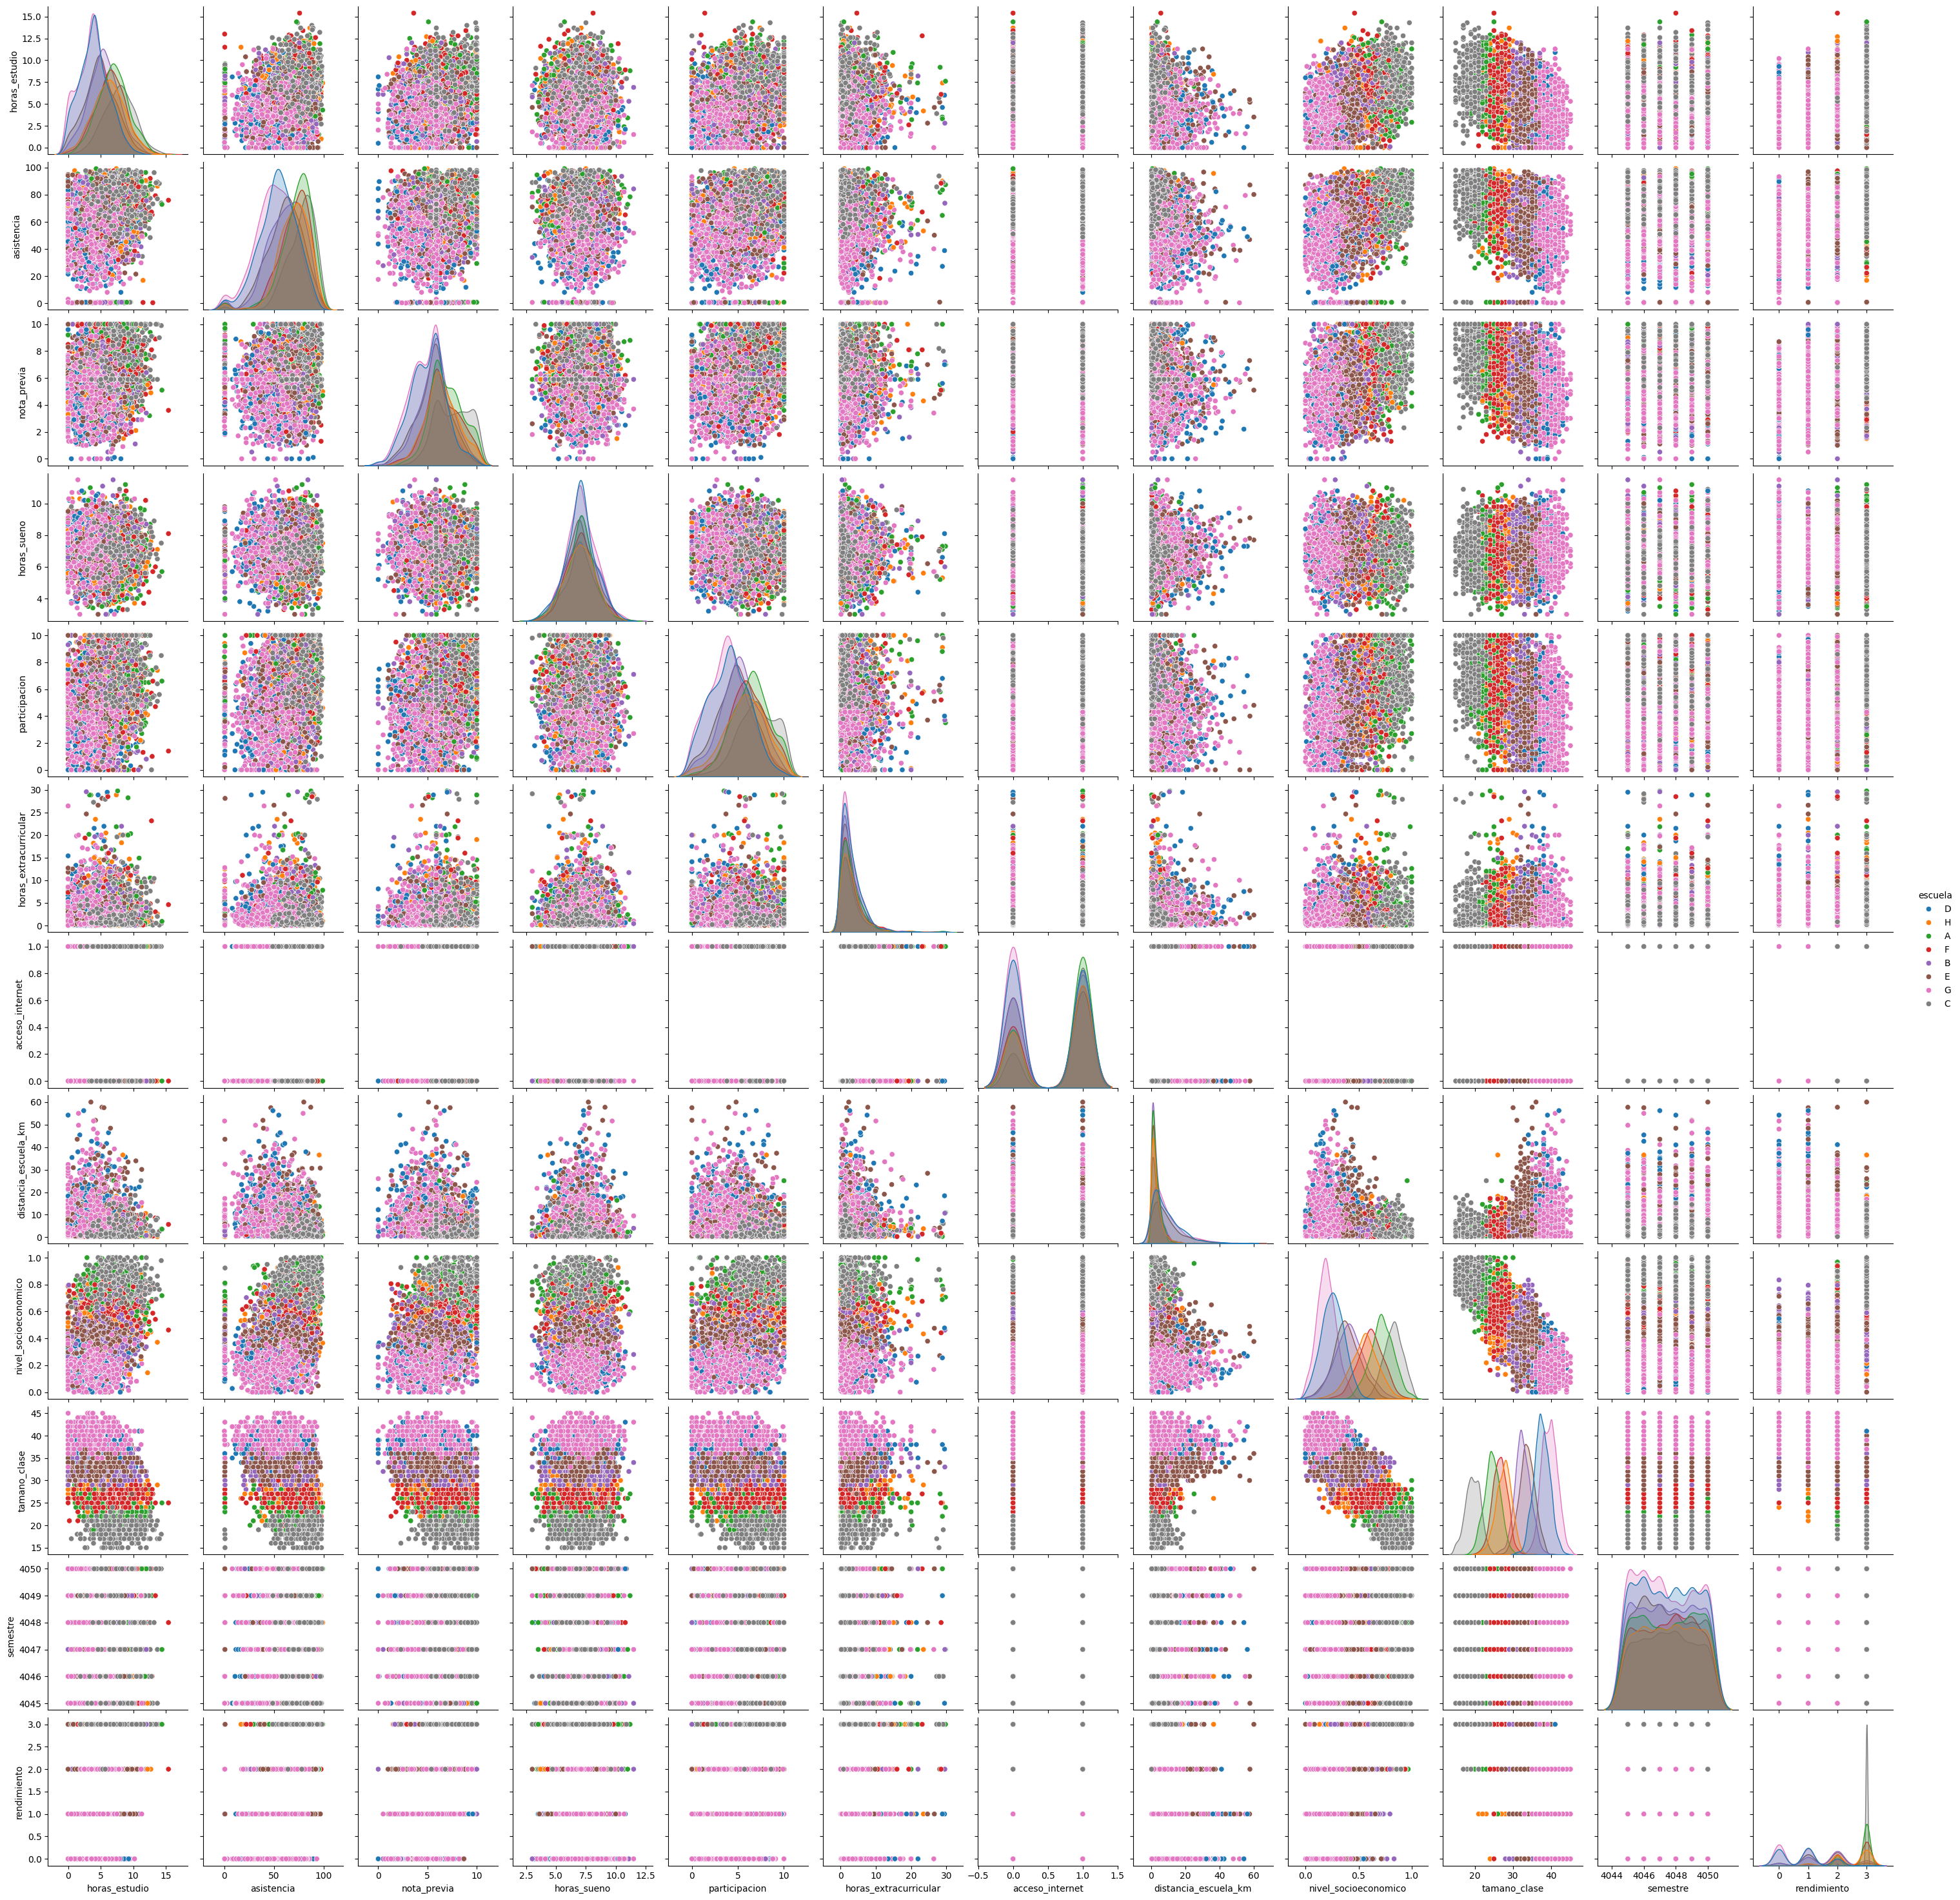

In [15]:
sns.pairplot(data_total, hue="escuela")

Al analizar las variables segmentadas por escuela, se observa que, en general, las distribuciones dentro de cada grupo presentan formas aproximadamente normales, concentrándose en valores intermedios.
Por otro lado, no se identifican correlaciones fuertes entre la mayoría de las variables. Sin embargo, se destaca una relación negativa entre nivel_socioeconomico y tamano_clase, lo que sugiere que, a mayor nivel socioeconómico, el tamaño de la clase tiende a ser menor. Esto explica lo que se había previamente mencionado sobre las escuelas y el tamaño de clase, dando a entender que las de mayor nivel socioeconómico suelen tener clases mas pequeñas.

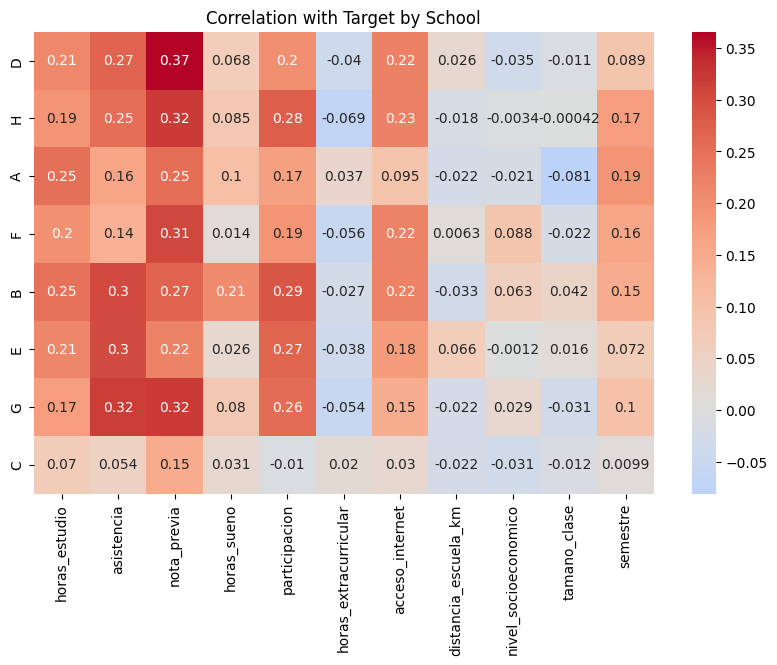

In [14]:
corr_list = []

for escuela in data_total["escuela"].unique():
    
    df_esc = data_total[data_total["escuela"] == escuela]
    
    corr = df_esc.corr(numeric_only=True)["rendimiento"]
    
    corr.name = escuela 
    
    corr_list.append(corr)

corr_by_school = pd.DataFrame(corr_list)
corr_by_school = corr_by_school.drop(columns=["rendimiento"], errors="ignore")

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_by_school,
    annot=True,
    cmap="coolwarm",
    center=0
) 

plt.title("Correlation with Target by School")
plt.show()

No se observan diferencias significativas en la correlación entre las variables y la variable objetivo al segmentar por escuela. En general, las correlaciones son relativamente bajas y consistentes entre instituciones, lo que sugiere que la relación entre las variables explicativas y el rendimiento no varía sustancialmente según la escuela.

Resulta llamativo que variables intuitivamente relevantes, como horas_estudio, presenten correlaciones bajas con la variable objetivo. Esto podría indicar que la relación no es lineal, que existen otros factores que influyen con mayor peso en el rendimiento, o que el efecto de estas variables se manifiesta en combinación con otras.

Por otro lado, nota_previa es la variable que presenta la mayor correlación con el rendimiento en todas las escuelas, lo cual es consistente con lo esperado, ya que el desempeño pasado suele ser un buen predictor del desempeño futuro.

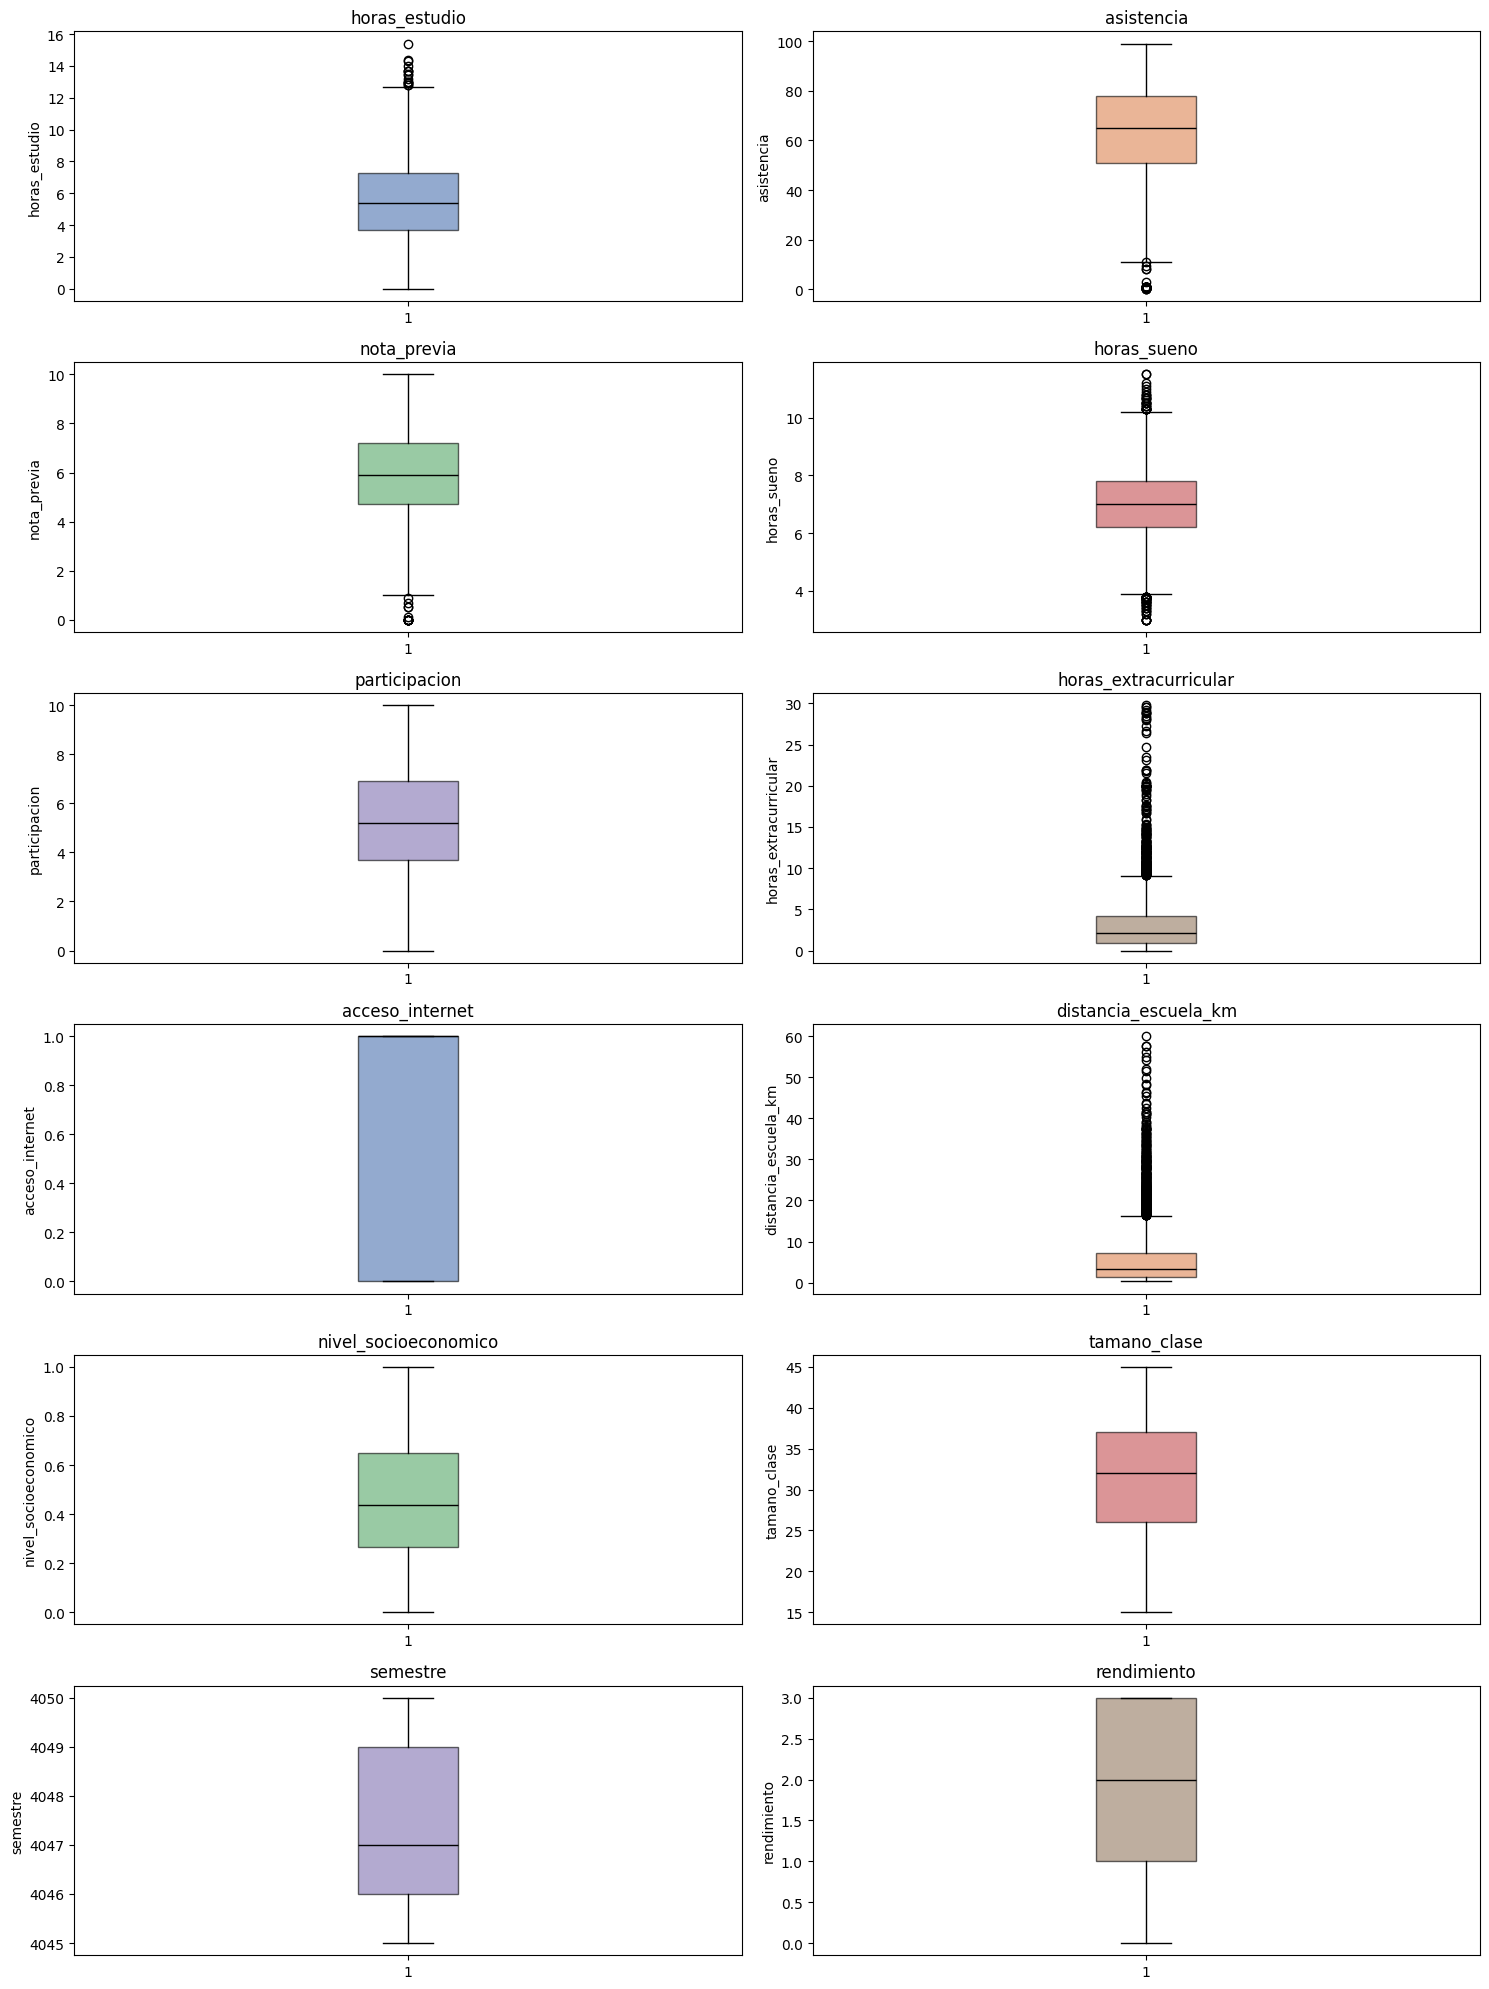

In [ ]:
features_analysis = data_total.select_dtypes(include=["float64", "int64"]).columns

n_features = len(features_analysis)
n_cols = 2
n_rows = (n_features + 1) // n_cols

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.ravel()

for i, feature in enumerate(features_analysis):
    
    bp = axes[i].boxplot(data_total[feature], patch_artist=True)
    
    bp["boxes"][0].set_facecolor(colors[i % len(colors)])
    bp["boxes"][0].set_alpha(0.6)
    bp["medians"][0].set_color("black")
    
    axes[i].set_title(feature)
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

Se identificaron valores atípicos en variables como distancia_escuela_km, horas_extracurricular, horas_estudio y horas_sueno. Sin embargo, estos valores no corresponden a errores en los datos, sino a observaciones poco frecuentes pero plausibles dentro del contexto del problema (por ejemplo, estudiantes que viven lejos o dedican muchas horas a actividades). Por este motivo, no se optará por eliminar dichos valores, ya que su exclusión podría implicar una pérdida de información relevante para el modelo. En su lugar, para aquellas variables que presentan distribuciones fuertemente sesgadas, como distancia_escuela_km y horas_extracurricular, se aplicará una transformación logarítmica. Esta permite reducir el impacto de los valores extremos, comprimiendo las colas de la distribución y generando una forma más simétrica, lo cual resulta beneficioso para el desempeño de modelos lineales.

In [ ]:
for data in [data_train, train, val, data_test]:
    data["distancia_escuela_km"] = np.log1p(data["distancia_escuela_km"])
    data["horas_extracurricular"] = np.log1p(data["horas_extracurricular"])

display(data_test)

,horas_estudio,asistencia,nota_previa,horas_sueno,participacion,horas_extracurricular,acceso_internet,distancia_escuela_km,nivel_socioeconomico,tamano_clase,escuela,semestre,rendimiento
0,1.4,41.400,6.6,8.0,4.2,2.332144,1,1.887070,0.417,38,D,4051,1
1,4.5,55.800,6.7,8.2,5.2,1.163151,0,0.262364,0.451,30,H,4051,2
2,5.6,0.419,6.7,7.7,4.8,0.916291,1,2.949688,0.245,37,D,4051,2
3,6.5,64.000,4.0,5.2,3.7,2.251292,0,1.757858,0.057,38,G,4051,0
4,8.1,77.500,3.5,7.9,5.3,2.557227,1,1.824549,0.693,25,F,4051,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
790,5.4,59.900,5.9,9.0,5.3,1.098612,0,2.240710,0.230,41,D,4051,1
791,6.8,29.700,2.3,7.2,4.4,0.641854,0,2.580217,0.220,35,D,4051,1
792,6.7,22.500,4.7,7.1,2.1,0.875469,0,0.993252,0.127,41,G,4051,0
793,9.5,61.700,5.8,5.4,7.0,2.302585,0,2.674149,0.423,34,E,4051,2


In [ ]:
train_print, val_print, data_test_print = one_hot_encoder_school(train.copy(), val.copy(), data_test.copy())
data_total = pd.concat([train_print, val_print], axis=0).reset_index(drop=True)

data_total.to_csv("../data/processed/rendimiento_estudiantes_dev_processed.csv", index=False)
data_test_print.to_csv("../data/processed/rendimiento_estudiantes_test_processed.csv", index=False)

# Clasificación Binaria y Estrategias de Splitting


In [ ]:
data_train["rendimiento"] = data_train.copy()["rendimiento"].map(notes)
data_train["target_b"] = (data_train.copy()["rendimiento"] != 0).astype(int)
data_train["semestre"] = data_train.copy()["semestre"].apply(semestre_to_int)

features = [col for col in data_train.select_dtypes(include=["float64", "int64"]).columns 
            if col not in ["target_b"]]

train_school, val_school = group_split_by_school(data_train, num_schools_val=2, random_state=42)
train_random, val_random = random_split(data_train, test_size=0.2, random_state=42)
train_temporal, val_temporal = temporal_split(data_train)

results = []

for train_set, val_set, name in zip(
    [train_school, train_random, train_temporal],
    [val_school, val_random, val_temporal],
    ["Group by School", "Random Split", "Temporal Split"]
):
    print(f"\n===== {name} =====")

    train_set, val_set = preprocess(train_set, val_set, features)

    X_train = train_set.drop(columns=["rendimiento", "target_b"]).values.astype(float)
    y_train = train_set["target_b"].values
    
    X_val = val_set.drop(columns=["rendimiento", "target_b"]).values.astype(float)
    y_val = val_set["target_b"].values

    print(f"X Training samples: {len(X_train)}, Validation samples: {len(X_val)}")
    print(f"Y Training samples: {len(y_train)}, Validation samples: {len(y_val)}")

    model = BinaryLogisticRegression(X_train, y_train, L2=0.1)
    model.fit(L2=True)
    
    y_pred = model.prediction(X_val)
    y_prob = model.probability(X_val)
    
    print_confusion_matrix(y_val, y_pred)
    print_metrics(y_val, y_pred, title=f"{name} - Metrics")

    results.append({"name": name, "y_true": y_val, "y_prob": y_prob})


===== Group by School =====
X Training samples: 3898, Validation samples: 1160
Y Training samples: 3898, Validation samples: 1160
Confusion Matrix:
TP: 1097 | FP: 53
FN: 6 | TN: 4

Group by School - Metrics:
Accuracy: 0.9491
Precision: 0.9539
Recall: 0.9946
F1 Score: 0.9738

===== Random Split =====
X Training samples: 4046, Validation samples: 1012
Y Training samples: 4046, Validation samples: 1012
Confusion Matrix:
TP: 842 | FP: 130
FN: 6 | TN: 34

Random Split - Metrics:
Accuracy: 0.8656
Precision: 0.8663
Recall: 0.9929
F1 Score: 0.9253

===== Temporal Split =====
X Training samples: 4211, Validation samples: 847
Y Training samples: 4211, Validation samples: 847
Confusion Matrix:
TP: 735 | FP: 86
FN: 2 | TN: 24

Temporal Split - Metrics:
Accuracy: 0.8961
Precision: 0.8952
Recall: 0.9973
F1 Score: 0.9435


Si bien se esperaría una caída significativa en el desempeño al utilizar estrategias como group split o temporal split, los resultados muestran métricas elevadas en todos los casos. Esto se debe principalmente al fuerte desbalance de la variable objetivo, donde la clase positiva es ampliamente mayoritaria. En este contexto, el modelo tiende a predecir la clase dominante, logrando altos valores de accuracy, precision, recall y F1-score.

Sin embargo, al analizar la matriz de confusión, se observa que el modelo presenta un bajo desempeño en la identificación de la clase minoritaria, evidenciado por una baja cantidad de verdaderos negativos y una alta proporción de falsos positivos. Esto sugiere que, si bien las métricas globales son altas, el modelo no está capturando adecuadamente la estructura de la clase minoritaria.

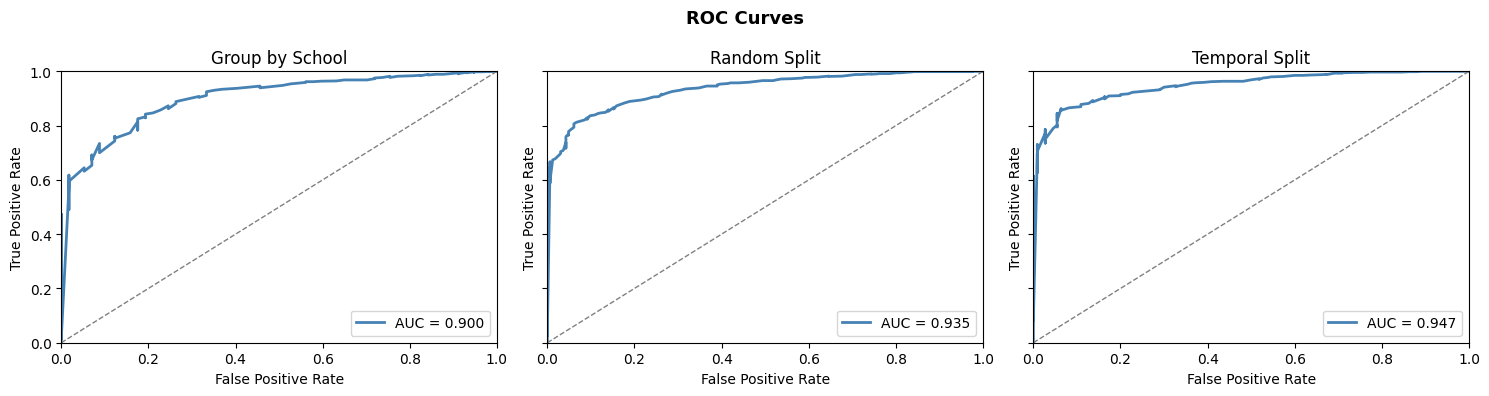

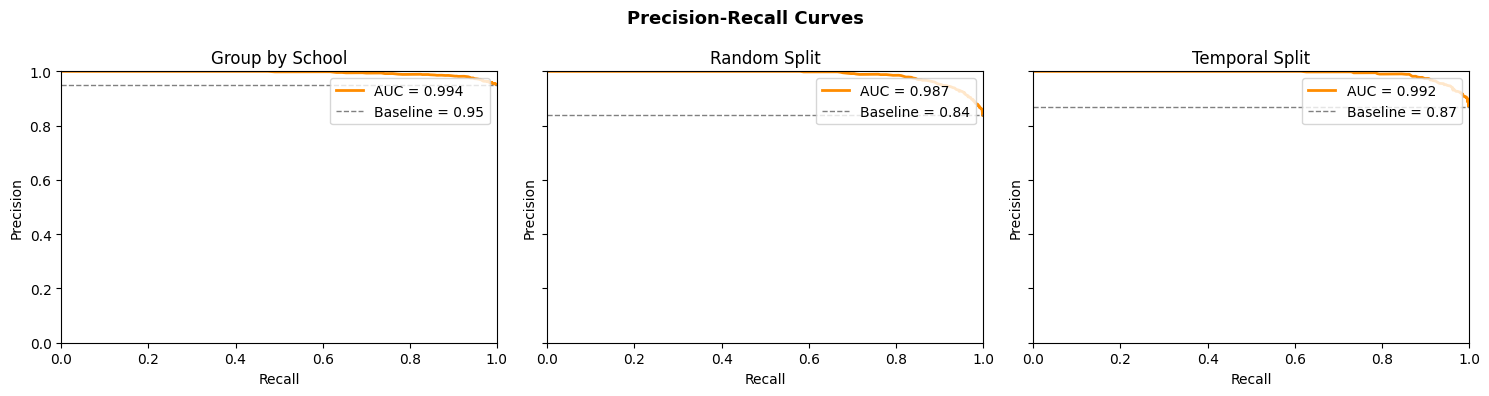

In [ ]:
plot_roc_curves(results)
plot_pr_curves(results)

En el gráfico ROC las tres curvas se ubican muy por encima de la diagonal, lo que indica que el modelo distingue bien entre clases en todos los casos. El AUC más bajo corresponde al Group Split (0.896), lo cual es esperable: al entrenar sin datos de 2 escuelas y validar sobre ellas, el modelo enfrenta distribuciones no vistas, lo que dificulta la generalización. El Random Split y el Temporal Split obtienen AUCs similares y más altos (0.935 y 0.947), ya que en ambos casos todas las escuelas están representadas en entrenamiento. Por esta razón se concluye que el model no generaliza bien por problemas de calibración del threshold.

Los AUC-PR son muy altos en los tres casos (>0.98), pero esto debe interpretarse con cuidado dado el fuerte desbalance de clases — la baseline (proporción de positivos) es de 0.95, 0.84 y 0.87 según el split. Con tanta clase positiva, un modelo que predice casi siempre 1 ya obtiene precision alta naturalmente. Por eso la curva PR no cae demasiado incluso en el Group Split. La métrica más informativa en este contexto es el comportamiento en los extremos de recall bajo, donde se puede observar que el modelo sí logra precision cercana a 1 cuando es más selectivo, lo que sugiere que las features aportan información real más allá del sesgo de clase.

In [ ]:
lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

print("KFold aleatorio:")
f1_kfold, best_lam_kfold, splitsA = cross_validate(data_train, lambdas, features, preprocess, BinaryLogisticRegression, f1_score, k=5, group=False)

print("\nGroupKFold por escuela:")
f1_group, best_lam_group, splitsG = cross_validate(data_train, lambdas, features, preprocess, BinaryLogisticRegression, f1_score, group=True)

# Temporal: loop manual sobre lambdas
print("\nTemporal:")
f1_temporal = []
train_t, val_t = temporal_split(data_train)
for lam in lambdas:
    train_p, val_p = preprocess(train_t.copy(), val_t.copy(), features)
    X_train = train_p.drop(columns=["rendimiento", "target_b"]).values.astype(float)
    y_train = train_p["target_b"].values
    X_val   = val_p.drop(columns=["rendimiento", "target_b"]).values.astype(float)
    y_val   = val_p["target_b"].values
    model = BinaryLogisticRegression(X_train, y_train, L2=lam)
    model.fit(L2=True, iters=10000)
    f1_temporal.append(f1_score(y_val, model.prediction(X_val)))
    print(f"  λ={lam:.4f} -> F1={f1_temporal[-1]:.4f}")

KFold aleatorio:
  λ=0.0001 -> F1=0.9400
  λ=0.0010 -> F1=0.9401
  λ=0.0100 -> F1=0.9389
  λ=0.1000 -> F1=0.9246
  λ=1.0000 -> F1=0.9120
  λ=10.0000 -> F1=0.9120
  λ=100.0000 -> F1=0.9120

GroupKFold por escuela:
  λ=0.0001 -> F1=0.9333
  λ=0.0010 -> F1=0.9326
  λ=0.0100 -> F1=0.9301
  λ=0.1000 -> F1=0.9139
  λ=1.0000 -> F1=0.9120
  λ=10.0000 -> F1=0.9120
  λ=100.0000 -> F1=0.9120

Temporal:
  λ=0.0001 -> F1=0.9524
  λ=0.0010 -> F1=0.9524
  λ=0.0100 -> F1=0.9500
  λ=0.1000 -> F1=0.9435
  λ=1.0000 -> F1=0.9306
  λ=10.0000 -> F1=0.9306
  λ=100.0000 -> F1=0.9306


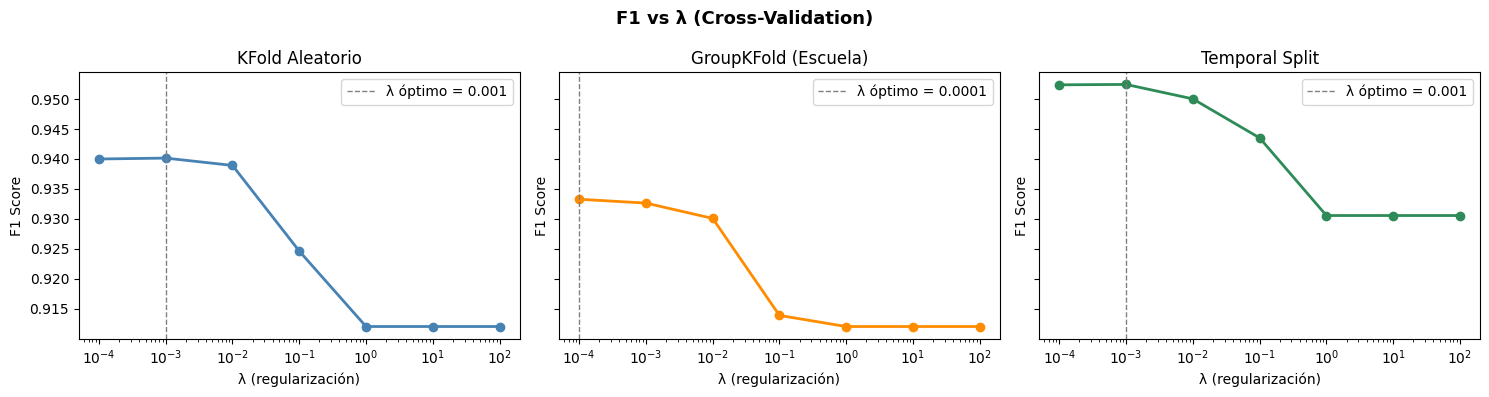

In [ ]:
plot_cv_f1(lambdas, f1_kfold, f1_group, f1_temporal)

En los tres casos el F1 cae monotónicamente a medida que aumenta λ con el óptimo en 0.0001. Esto sugiere que la regularización fuerte perjudica al modelo. Con tanto desbalance de clases, penalizar los pesos hace que el modelo se vuelva aún más conservador y pierda capacidad para detectar la clase minoritaria.

Temporal Split es el que mejor F1 Score consiguió, por lo que parece ser el mejor split de los 3.

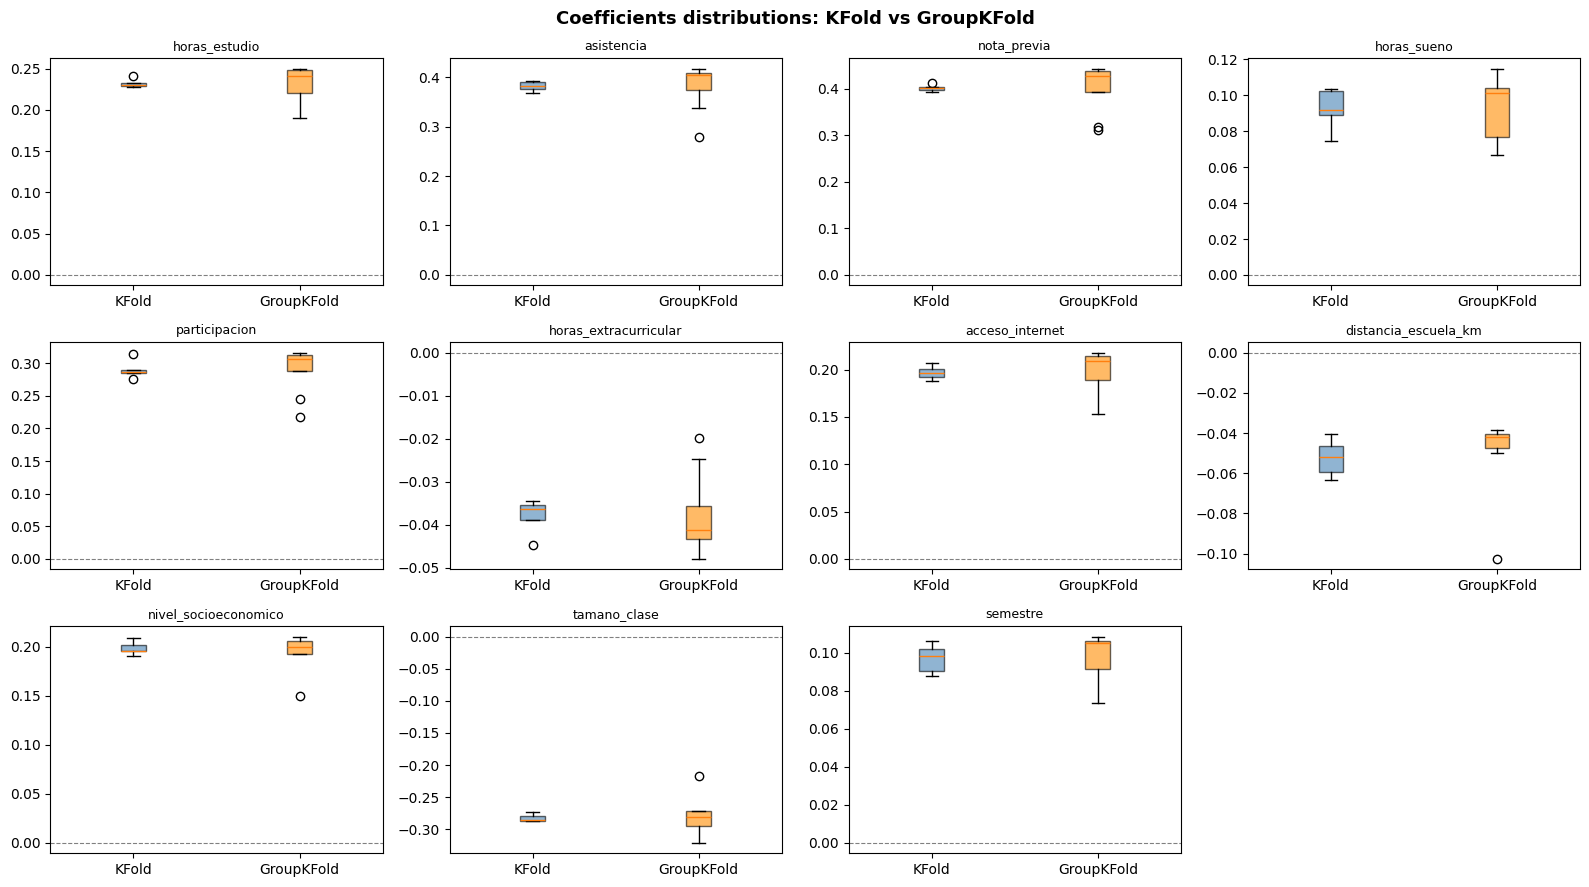

In [ ]:
weights_kfold, feature_names = show_weights(data_train, features, best_lam_kfold, splitsA, preprocess, BinaryLogisticRegression)

weights_group, _ = show_weights(data_train, features, best_lam_group, splitsG, preprocess, BinaryLogisticRegression)

plot_coefficient_stability(weights_kfold, weights_group, feature_names)

nota_previa, participacion, distancia_escuela_km y tamano_clase son las que muestran mayor inestabilidad bajo GroupKFold, evidenciado por cajas más anchas y outliers que no aparecen en KFold. Estas features tienen coeficientes que varían significativamente dependiendo de qué escuelas están en train.

Que un coeficiente sea inestable implica que el efecto de esa feature sobre el target no es universal sino que está confundido con características propias de cada escuela. El modelo no está capturando una relación puramente individual del estudiante sino algo mezclado con el contexto escolar. En producción, si se trata de predecir una escuela nueva, estos coeficientes serán los menos confiables. Por otro lado, que los coeficientes sean estables indica que el efecto de las variables es consistente independientemente de qué escuelas estén en train. Son features con una relación robusta con el target.

### ¿Cuándo usar cada estrategia?

- KFold aleatorio: Se usa si en producción el modelo va a predecir sobre estudiantes de las mismas escuelas con las que fue entrenado.

- GroupKFold: Útil si el modelo va a predecir el rendimiento en escuelas nuevas no vistas durante el entrenamiento.

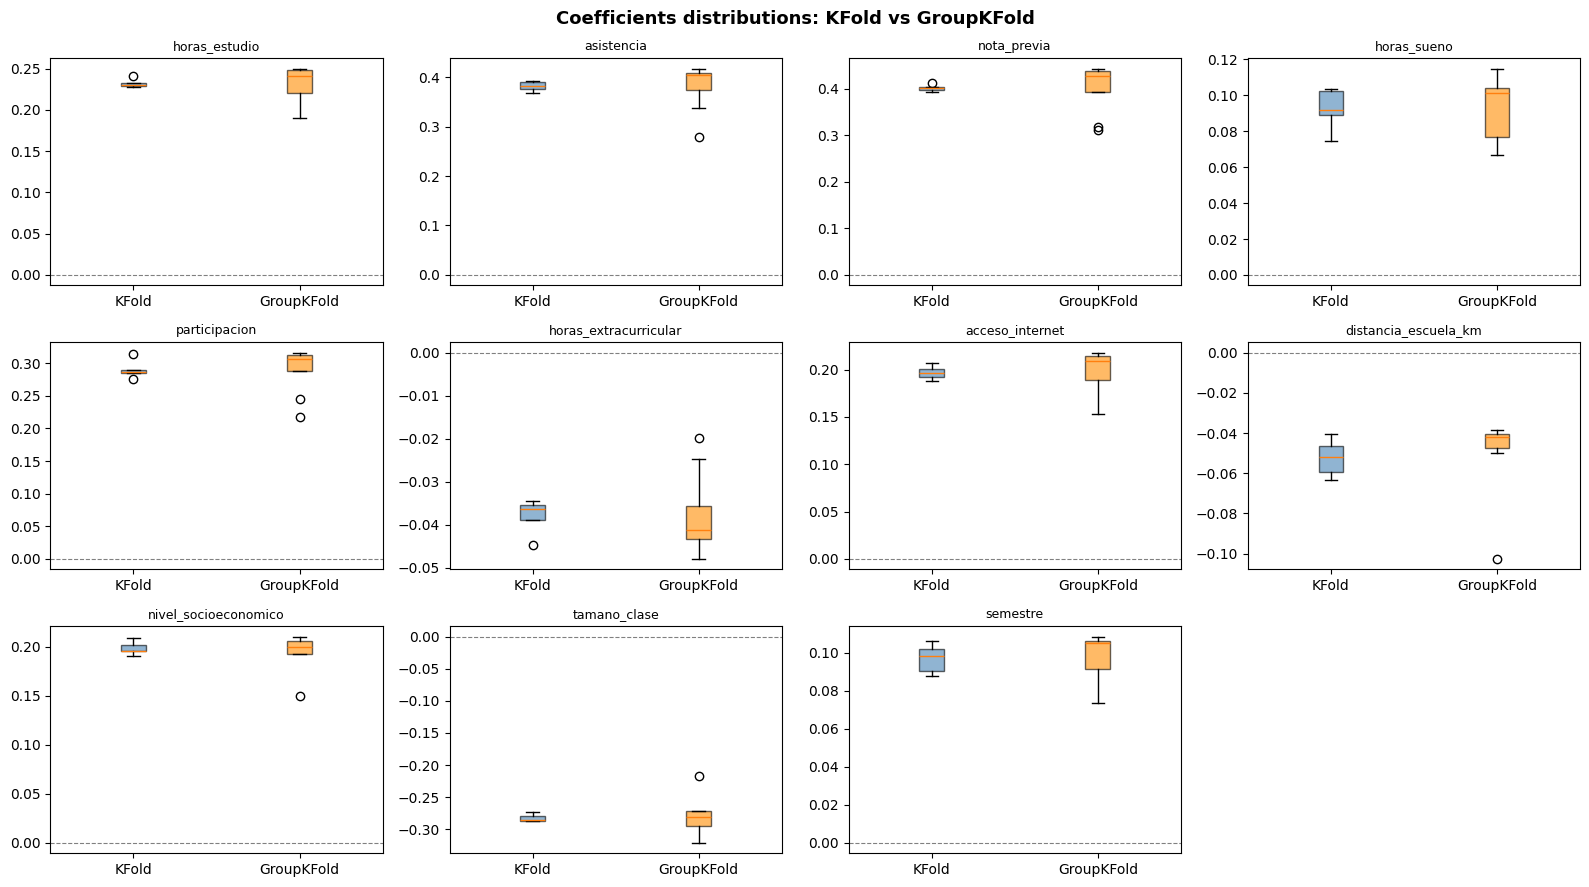

In [ ]:
features = [col for col in data_train.select_dtypes(include=["float64", "int64"]).columns 
            if col not in ["target_b", "escuela"]]

weights_kfold, feature_names = show_weights(data_train, features, best_lam_kfold, splitsA, preprocess, BinaryLogisticRegression)

weights_group, _ = show_weights(data_train, features, best_lam_group, splitsG, preprocess, BinaryLogisticRegression)

plot_coefficient_stability(weights_kfold, weights_group, feature_names)

Los resultados no cambian en absoluto y por ende el gap entre random split y group split se mantiene. Esto puede deberse a que la información de la escuela ya estaba implícitamente capturada por las otras features, entonces eliminar la columna de escuelas no genera cambio alguno. 

# Clasificación Multiclase y Ensemble Learning

In [ ]:
features_mc = [col for col in data_train.select_dtypes(include=["float64", "int64"]).columns 
               if col not in ["target_b", "rendimiento"]]

splits_group = Kfold_group(data_train)

all_y_true, all_y_pred_lda, all_y_prob_lda = [], [], []
all_y_pred_mlr, all_y_prob_mlr = [], []
all_y_pred_rf, all_y_prob_rf = [], []

features_with_oh = []

for train_idx, val_idx in splits_group:
    train_f = data_train.loc[train_idx].reset_index(drop=True)
    val_f = data_train.loc[val_idx].reset_index(drop=True)

    train_f, val_f = preprocess(train_f, val_f, features_mc)

    X_train = train_f.drop(columns=["rendimiento", "target_b"]).values.astype(float)
    y_train = train_f["rendimiento"].values
    X_val = val_f.drop(columns=["rendimiento", "target_b"]).values.astype(float)
    y_val = val_f["rendimiento"].values

    features_with_oh = train_f.drop(columns=["rendimiento", "target_b"]).columns.tolist()

    lda = LDA(X_train, y_train)
    lda.fit()

    mlr = MulticlassLogisticRegression(X_train, y_train, L2=0.01)
    mlr.fit(L2=True)

    rf = RandomForest(X_train, y_train, n_trees=100, max_depth=10, min_samples_leaf=5)
    rf.fit()

    all_y_true.extend(y_val)
    all_y_pred_lda.extend(lda.prediction(X_val)); all_y_prob_lda.extend(lda.probability(X_val))
    all_y_pred_mlr.extend(mlr.prediction(X_val)); all_y_prob_mlr.extend(mlr.probability(X_val))
    all_y_pred_rf.extend(rf.prediction(X_val)); all_y_prob_rf.extend(rf.probability(X_val))

y_val = np.array(all_y_true)
y_prob_lda = np.array(all_y_prob_lda)
y_prob_mlr = np.array(all_y_prob_mlr)
y_prob_rf = np.array(all_y_prob_rf)

Reached maximum iterations without convergence.
Final Loss: 0.8166
Reached maximum iterations without convergence.
Final Loss: 0.8361
Reached maximum iterations without convergence.
Final Loss: 0.8770
Reached maximum iterations without convergence.
Final Loss: 0.8504
Reached maximum iterations without convergence.
Final Loss: 0.8020
Reached maximum iterations without convergence.
Final Loss: 0.8008
Reached maximum iterations without convergence.
Final Loss: 0.8259
Reached maximum iterations without convergence.
Final Loss: 0.8974


Confusion Matrix:


,Insuficiente,Regular,Bueno,Excelente
Real \ Pred,,,,
Insuficiente,165,236,416,1
Regular,45,103,960,28
Bueno,17,42,1094,176
Excelente,5,8,750,1012


Confusion Matrix:


,Insuficiente,Regular,Bueno,Excelente
Real \ Pred,,,,
Insuficiente,300,489,29,0
Regular,239,634,213,50
Bueno,106,318,335,570
Excelente,10,32,77,1656


Confusion Matrix:


,Insuficiente,Regular,Bueno,Excelente
Real \ Pred,,,,
Insuficiente,132,506,179,1
Regular,48,499,557,32
Bueno,10,251,720,348
Excelente,0,34,276,1465



LDA
Clase             Accuracy  Precision     Recall         F1
-------------------------------------------------------
Insuficiente        0.8577     0.7112     0.2017     0.3143
Regular             0.7392     0.2648     0.0907     0.1351
Bueno               0.5332     0.3398     0.8232     0.4810
Excelente           0.8086     0.8316     0.5701     0.6765

MulticlassLR
Clase             Accuracy  Precision     Recall         F1
-------------------------------------------------------
Insuficiente        0.8274     0.4580     0.3667     0.4073
Regular             0.7349     0.4304     0.5581     0.4860
Bueno               0.7404     0.5122     0.2521     0.3379
Excelente           0.8539     0.7276     0.9330     0.8176

RandomForest
Clase             Accuracy  Precision     Recall         F1
-------------------------------------------------------
Insuficiente        0.8529     0.6947     0.1614     0.2619
Regular             0.7177     0.3868     0.4393     0.4114
Bueno              

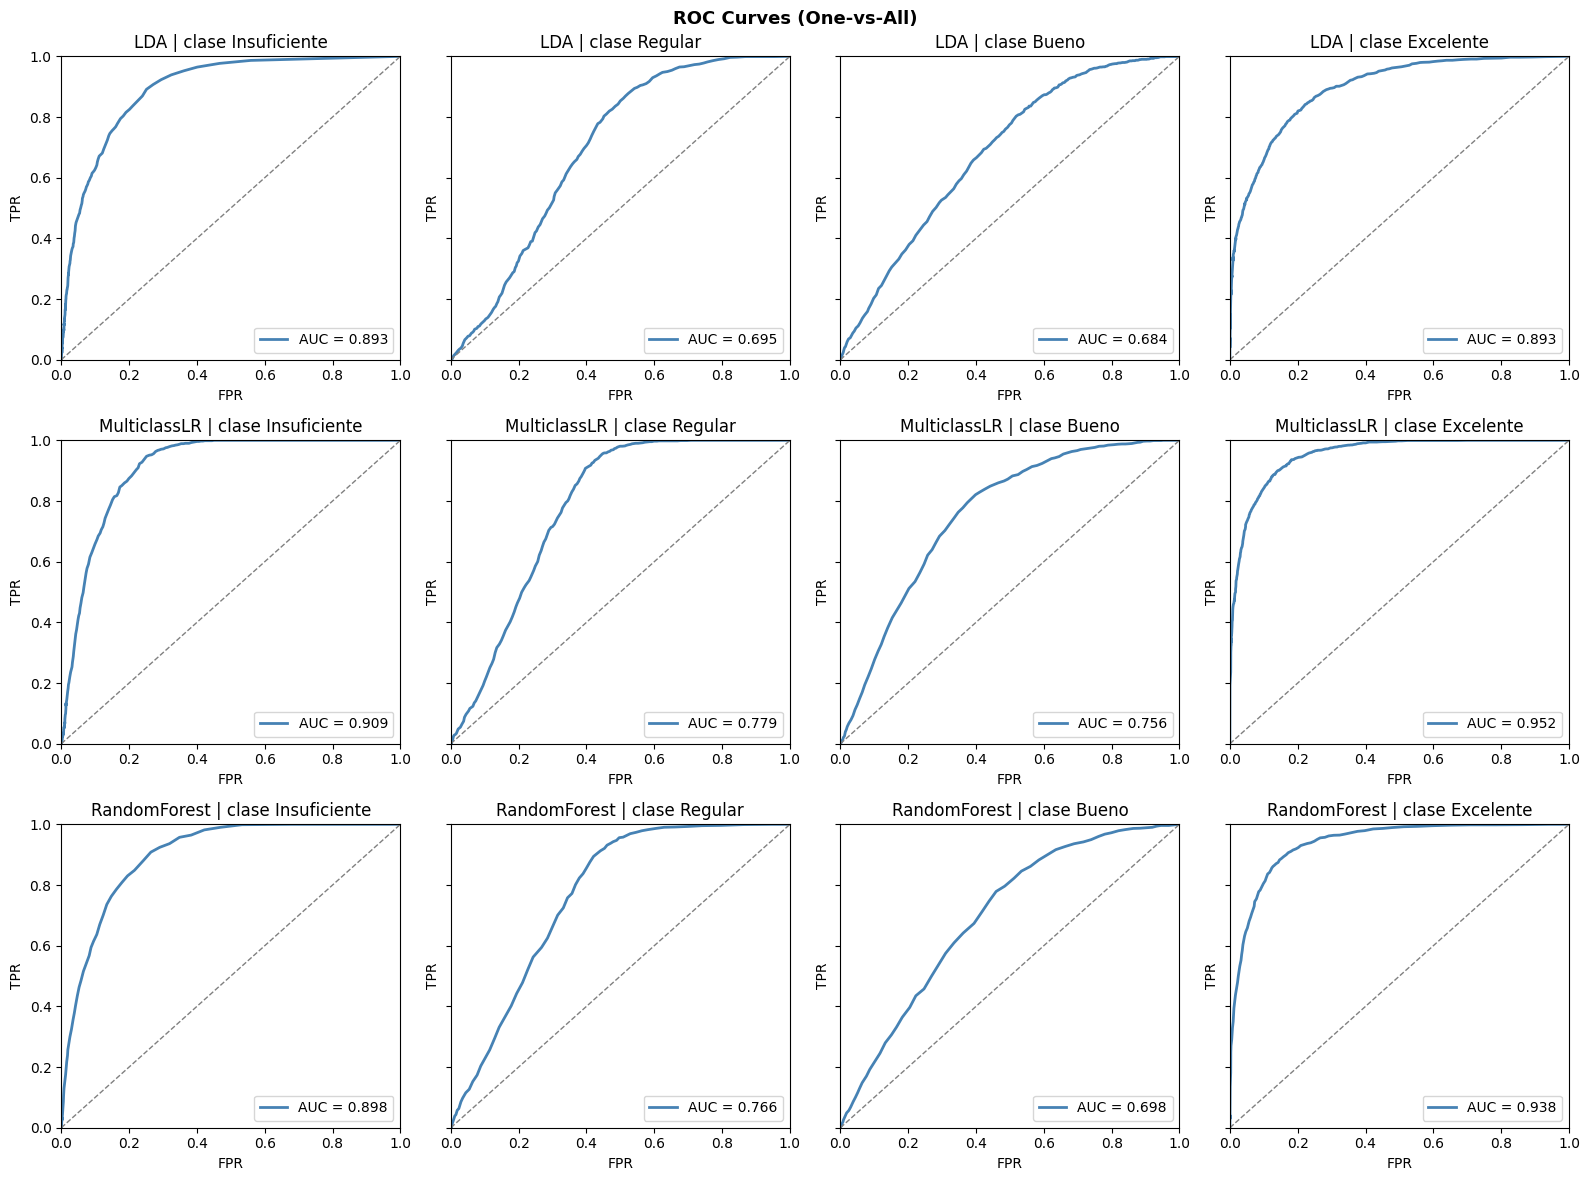

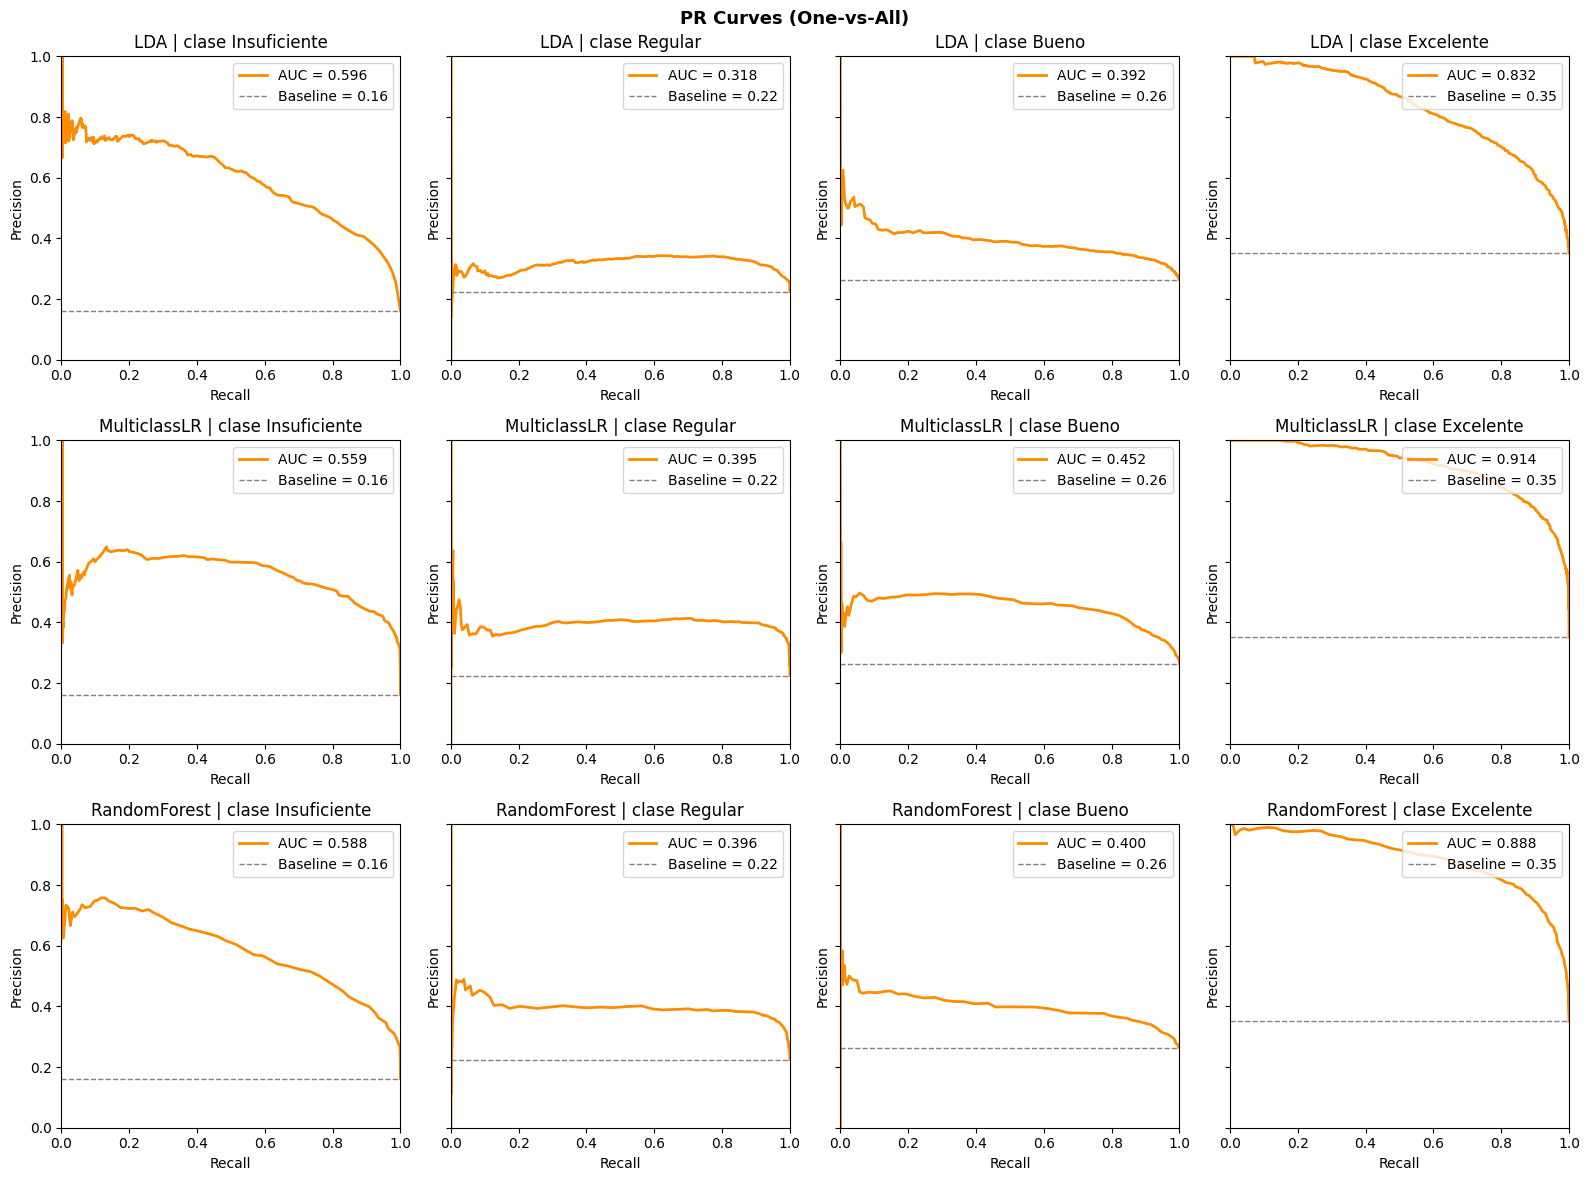

In [ ]:
classes = np.unique(y_val)
class_names = {v: k for k, v in notes.items()}

results_mc = [
    {"name": "LDA", "y_true": y_val, "y_prob": y_prob_lda},
    {"name": "MulticlassLR", "y_true": y_val, "y_prob": y_prob_mlr},
    {"name": "RandomForest", "y_true": y_val, "y_prob": y_prob_rf},
]

print_confusion_matrix_multiclass(y_val, np.array(all_y_pred_lda), class_names, classes)
print_confusion_matrix_multiclass(y_val, np.array(all_y_pred_mlr), class_names, classes)
print_confusion_matrix_multiclass(y_val, np.array(all_y_pred_rf), class_names, classes)

print_metrics_multiclass(y_val, np.array(all_y_pred_lda), classes, class_names, "LDA")
print_metrics_multiclass(y_val, np.array(all_y_pred_mlr), classes, class_names, "MulticlassLR")
print_metrics_multiclass(y_val, np.array(all_y_pred_rf),  classes, class_names, "RandomForest")

plot_roc_curves_multiclass(results_mc, classes, class_names)
plot_pr_curves_multiclass(results_mc, classes, class_names)

### Métricas:

Multiclass Logistic Regression es el mejor modelo overall, siendo dominante en casi todas las métricas sin importar la clase. Lo más importante es que lidera las métricas en la clase insuficiente que es la que realmente estamos evaluando y la más dificil de predecir ya que como vimos previamente en el análisis es la que menor cantidad de datos tiene. 

### ROC:

Los tres modelos se comportan de manera similar. Excelente tiene el AUC más alto en todos los modelos ya que es la clase más fácil de discriminar al ser la que más datos tiene. Bueno por otro lado, tiene el AUC más bajo en todos, consistente con que es la clase más difícil de separar del resto.

### PR:

Las curvas PR muestran que ningún modelo supera significativamente la baseline en Regular y Bueno, confirmando la dificultad de estas clases. En Excelente e Insuficiente sí hay ganancia real sobre la baseline. 

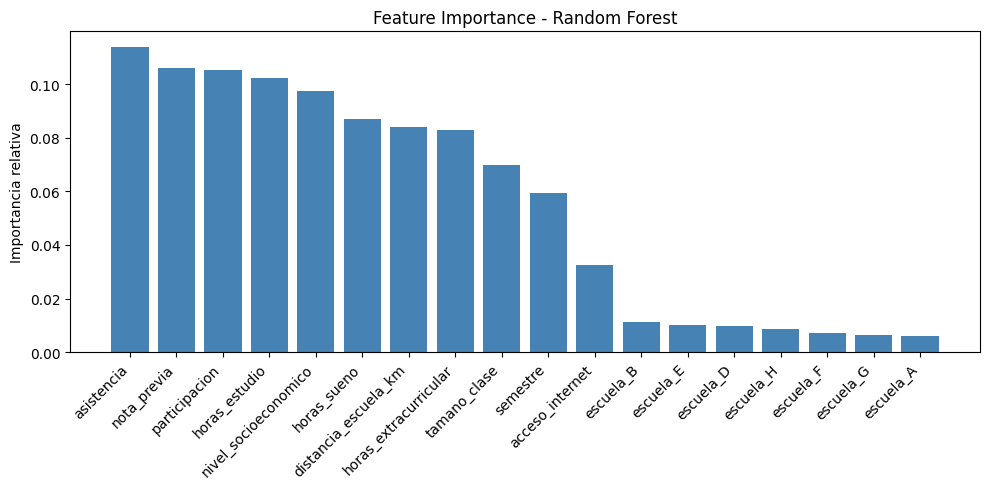

In [ ]:
importances = rf.feature_importance()

order = np.argsort(importances)[::-1]
sorted_features = [features_with_oh[i] for i in order]
sorted_importances = importances[order]

plt.figure(figsize=(10, 5))
plt.bar(sorted_features, sorted_importances, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importancia relativa")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

El gráfico muestra lo esperado, variables como la asistencia, participación y nota_previa reflejan el involucramiento y desempeño académico del estudiante, por lo tanto es común que conformen el podio. Conforme baja la importancia sigue habiendo sentido en las features involucradas a excepcion de acceso a internet, ya que parecería crucial para tener más eficiencia a la hora de estudiar. Las escuelas como era de esperar no aportan casi importancia ya que las demás features ya incluyen información sobre ellas.

# Manejo de Desbalance de Clases

,Accuracy,Precision,Recall,F1-Score,AUC-ROC,AUC-PR
No rebalance,0.8841,0.9022,0.9665,0.9333,0.9272,0.9858
Undersampling,0.7544,0.9960,0.7099,0.8290,0.9340,0.9872
Oversampling duplicate,0.7511,0.9950,0.7066,0.8264,0.9342,0.9872
Oversampling SMOTE,0.7544,0.9947,0.7108,0.8292,0.9341,0.9871
Cost re-weighting,0.7829,0.9912,0.7476,0.8524,0.9353,0.9874


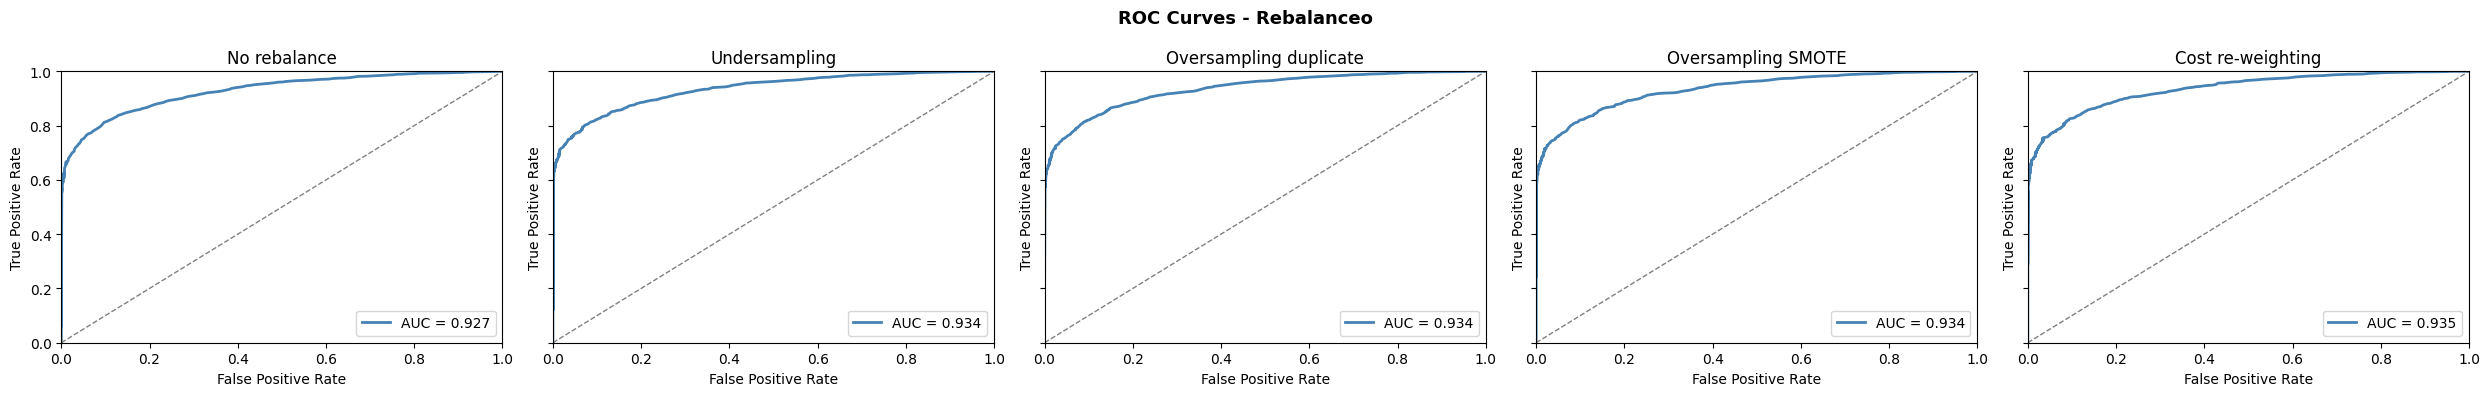

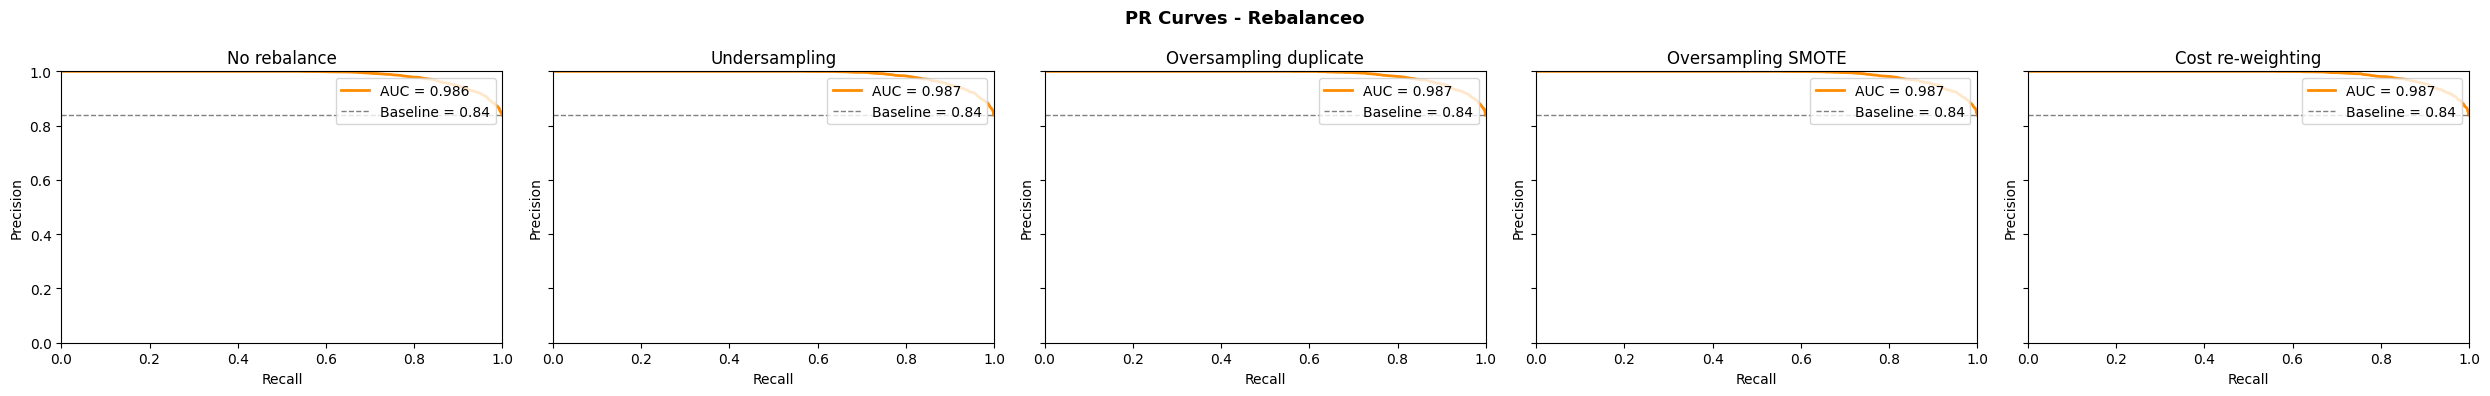

In [ ]:
splits_group = Kfold_group(data_train)

configs = {
    "No rebalance" : lambda X, y: (X, y),
    "Undersampling" : lambda X, y: undersample(X, y),
    "Oversampling duplicate" : lambda X, y: oversample_duplicate(X, y),
    "Oversampling SMOTE" : lambda X, y: oversample_smote(X, y),
    "Cost re-weighting" : lambda X, y: (X, y),
}

results_rebalance = {}

for method_name, rebalance in configs.items():
    all_y_true, all_y_pred, all_y_prob = [], [], []

    for train_idx, val_idx in splits_group:
        train_f = data_train.loc[train_idx].reset_index(drop=True)
        val_f = data_train.loc[val_idx].reset_index(drop=True)

        train_f, val_f = preprocess(train_f, val_f, features)

        X_train = train_f.drop(columns=["rendimiento", "target_b"]).values.astype(float)
        y_train = train_f["target_b"].values
        X_val = val_f.drop(columns=["rendimiento", "target_b"]).values.astype(float)
        y_val = val_f["target_b"].values

        X_res, y_res = rebalance(X_train, y_train)
        best_lam = cross_validate(X_train, )

        use_C = (method_name == "Cost re-weighting")
        model = BinaryLogisticRegression(X_res, y_res, L2=best_lam)
        model.fit(L2=True, C=use_C)

        all_y_true.extend(y_val)
        all_y_pred.extend(model.prediction(X_val))
        all_y_prob.extend(model.probability(X_val))

    y_true = np.array(all_y_true)
    y_pred = np.array(all_y_pred)
    y_prob = np.array(all_y_prob)

    _, _, auc_roc = roc_curve(y_true, y_prob)
    _, _, auc_pr = pr_curve(y_true, y_prob)

    results_rebalance[method_name] = {
        "accuracy" : accuracy(y_true, y_pred),
        "precision" : precision(y_true, y_pred),
        "recall" : recall(y_true, y_pred),
        "f1" : f1_score(y_true, y_pred),
        "auc_roc" : auc_roc,
        "auc_pr" : auc_pr,
        "y_true" : y_true,
        "y_prob" : y_prob,
    }

# Tabla
df_results = pd.DataFrame({
    method: {
        "Accuracy" : res["accuracy"],
        "Precision" : res["precision"],
        "Recall" : res["recall"],
        "F1-Score" : res["f1"],
        "AUC-ROC" : res["auc_roc"],
        "AUC-PR" : res["auc_pr"],
    }
    for method, res in results_rebalance.items()
}).T.round(4)

display(df_results)

# Curvas ROC y PR
results_plot = [{"name": k, "y_true": v["y_true"], "y_prob": v["y_prob"]} for k, v in results_rebalance.items()]
plot_roc_curves(results_plot, title="ROC Curves - Rebalanceo")
plot_pr_curves(results_plot, title="PR Curves - Rebalanceo")

Analizando las métricas y los gráficos, llego a la conclusión de que el split sin rebalanceo es el más efectivo. Aunque se podría argumentar que predice siempre 1 y por ende no identifica bien los desaprobados, es el líder en todas las métricas menos precision con un f1 score muy superior al resto. Si tiene menor área bajo la curva en ambos ROC y PR pero por cantidades casi insignificantes, por lo que para este modelo de aprobado y desaprobado parece muy eficiente. Empero, si estuviesemos evaluando si está o no está enfermo un paciente, donde es mucho más grave catalogar como sano alguien que no lo está, me inclinaría a perder accuracy y recall por una mejor precision y eligiría un modelo con rebalanceo. De todas maneras, para identificar los alumnos con bajo rendimiento si es más efectiva una técnica de rebalanceo. Por esta razón, utilizaré cost re-weighting

### Modelo APROBADO-DESAPROBADO

El modelo elegido para el caso binario es la regresión logistica con temporal split y corst re-weighting.
- temporal split tuvo el mejor f1 score en el cross validation.
- cost re-weighting tuvo el mejor overall en métricas entre las técnicas de rebalanceo, que como mencioné anteriormente son necesarias para identificar los no aprobados.

### Modelo Multiclase

El modelo elegido para el caso multiclase es multiclass logistic regression con groupk fold por escuela ya que es la que mejor predice el rendimiento insuficiente y tiene mejores metricas en general comparado con los otros dos modelos. No obstante ninguno de los modelos multiclase fue muy bueno para la clasificación de las notas de cada estudiante.

Confusion Matrix:
TP: 586 | FP: 2
FN: 120 | TN: 87

Binario - Test:
Accuracy: 0.8465
Precision: 0.9966
Recall: 0.8300
F1 Score: 0.9057


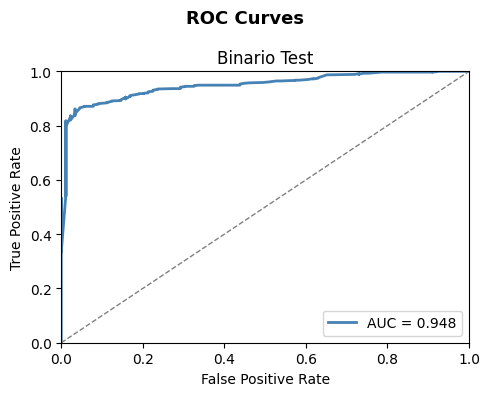

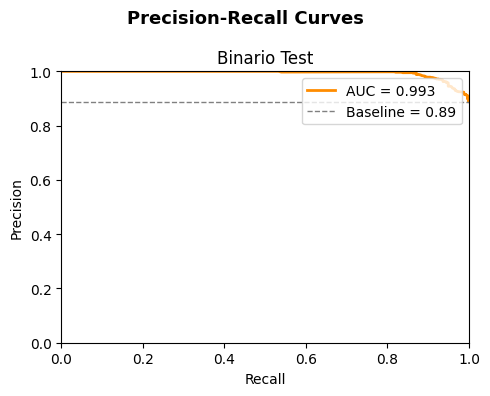

In [ ]:
data_test["target_b"] = (data_test.copy()["rendimiento"] != 0).astype(int)

data_train_b, data_test_b = preprocess(data_train.copy(), data_test.copy(), features)

X_train_final = data_train_b.drop(columns=["rendimiento", "target_b"]).values.astype(float)
y_train_final = data_train_b["target_b"].values
X_test = data_test_b.drop(columns=["rendimiento", "target_b"]).values.astype(float)
y_test = data_test_b["target_b"].values

model_b = BinaryLogisticRegression(X_train_final, y_train_final, L2=best_lam)
model_b.fit(L2=True, C=True)

y_pred_test = model_b.prediction(X_test)
y_prob_test = model_b.probability(X_test)

print_confusion_matrix(y_test, y_pred_test)
print_metrics(y_test, y_pred_test, title="Binario - Test")

results_test_b = [{"name": "Binario Test", "y_true": y_test, "y_prob": y_prob_test}]
plot_roc_curves(results_test_b)
plot_pr_curves(results_test_b)

Reached maximum iterations without convergence.
Final Loss: 0.8415
Confusion Matrix:


,Insuficiente,Regular,Bueno,Excelente
Real \ Pred,,,,
Insuficiente,62,26,1,0
Regular,46,87,28,3
Bueno,5,44,87,67
Excelente,0,2,26,311



Multiclase - Test
Clase             Accuracy  Precision     Recall         F1
-------------------------------------------------------
Insuficiente        0.9019     0.5487     0.6966     0.6139
Regular             0.8126     0.5472     0.5305     0.5387
Bueno               0.7849     0.6127     0.4286     0.5043
Excelente           0.8767     0.8163     0.9174     0.8639


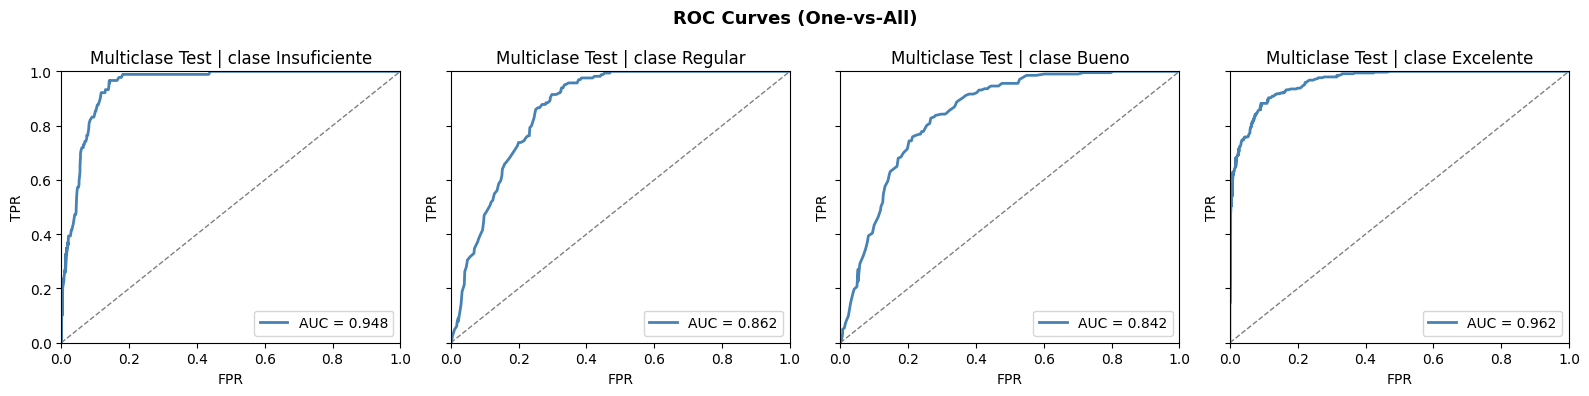

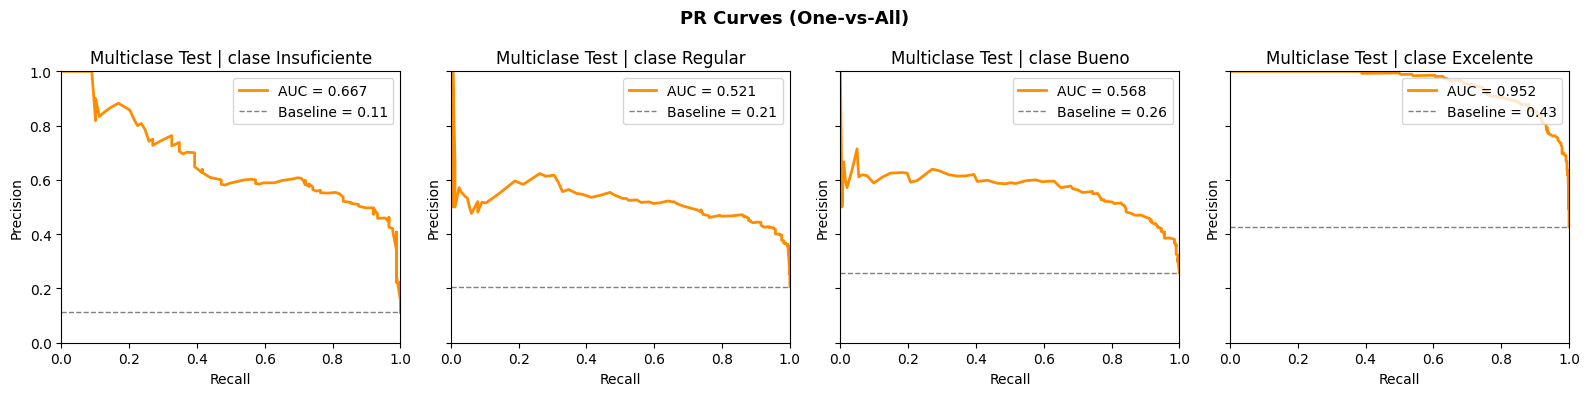

In [ ]:
data_train_mc, data_test_mc = preprocess(data_train.copy(), data_test.copy(), features_mc)

X_train_mc = data_train_mc.drop(columns=["rendimiento", "target_b"]).values.astype(float)
y_train_mc = data_train_mc["rendimiento"].values
X_test_mc  = data_test_mc.drop(columns=["rendimiento", "target_b"]).values.astype(float)
y_test_mc  = data_test_mc["rendimiento"].values

mlr_final = MulticlassLogisticRegression(X_train_mc, y_train_mc, L2=0.01)
mlr_final.fit(L2=True)

y_pred_mc = mlr_final.prediction(X_test_mc)
y_prob_mc = mlr_final.probability(X_test_mc)

classes_mc = np.unique(y_test_mc)

print_confusion_matrix_multiclass(y_test_mc, y_pred_mc, class_names, classes_mc)
print_metrics_multiclass(y_test_mc, y_pred_mc, classes_mc, title="Multiclase - Test", class_names=class_names)

results_test_mc = [{"name": "Multiclase Test", "y_true": y_test_mc, "y_prob": y_prob_mc}]
plot_roc_curves_multiclass(results_test_mc, classes_mc, class_names)
plot_pr_curves_multiclass(results_test_mc, classes_mc, class_names)

  n=389 -> accuracy=0.4948
  n=779 -> accuracy=0.5293
  n=1169 -> accuracy=0.5267
  n=1559 -> accuracy=0.5147
  n=1949 -> accuracy=0.5405
  n=2338 -> accuracy=0.5440
  n=2728 -> accuracy=0.5440
  n=3118 -> accuracy=0.5440
  n=3508 -> accuracy=0.5336
  n=3898 -> accuracy=0.5328
Current Accuracy:   0.5328
Target Accuracy: 0.5428
Datos necesarios totales: 4380
Datos nuevos a agregar:   482


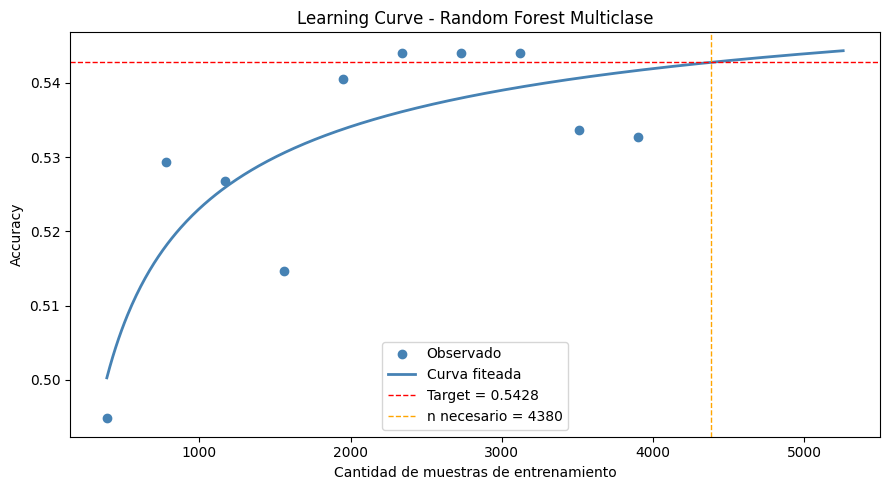

In [ ]:
# Fix split for the learning curve
train_lc, val_lc = group_split_by_school(data_train, num_schools_val=2, random_state=42)
train_lc, val_lc = preprocess(train_lc, val_lc, features_mc)

X_train_lc = train_lc.drop(columns=["rendimiento", "target_b"]).values.astype(float)
y_train_lc = train_lc["rendimiento"].values
X_val_lc   = val_lc.drop(columns=["rendimiento", "target_b"]).values.astype(float)
y_val_lc   = val_lc["rendimiento"].values

# Subsets for learning curve
fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
n_total = len(X_train_lc)
ns, accs = [], []

for frac in fractions:
    n = int(n_total * frac)
    idx = np.random.choice(n_total, n, replace=False)
    rf_lc = RandomForest(X_train_lc[idx], y_train_lc[idx], n_trees=50, max_depth=10, min_samples_leaf=5)
    rf_lc.fit()
    acc = accuracy(y_val_lc, rf_lc.prediction(X_val_lc))
    ns.append(n)
    accs.append(acc)
    print(f"  n={n} -> accuracy={acc:.4f}")

x = 1 / np.sqrt(np.array(ns, dtype=float))
y = np.array(accs)

# np.polyfit(x, y, 1) fits y = b0*x + b1 
coeffs = np.polyfit(x, y, 1)
b = -coeffs[0]
a =  coeffs[1]

# Take analytic form of the curve to calculate n needed for target accuracy
current_acc = accs[-1]
target_acc  = current_acc + 0.01
print(f"Current Accuracy:   {current_acc:.4f}")
print(f"Target Accuracy: {target_acc:.4f}")

# Solve for n
n_needed = (b / (a - target_acc)) ** 2
n_extra  = int(n_needed) - n_total
print(f"Datos necesarios totales: {int(n_needed)}")
print(f"Datos nuevos a agregar:   {n_extra}")

n_extrap = np.linspace(ns[0], n_needed * 1.2, 500)
plt.figure(figsize=(9, 5))
plt.plot(ns, accs, "o", color="steelblue", label="Observado")
plt.plot(n_extrap, a - b / np.sqrt(n_extrap), color="steelblue", lw=2, label="Curva fiteada")
plt.axhline(y=target_acc, color="red", linestyle="--", lw=1, label=f"Target = {target_acc:.4f}")
plt.axvline(x=n_needed, color="orange", linestyle="--", lw=1, label=f"n necesario = {int(n_needed)}")
plt.xlabel("Cantidad de muestras de entrenamiento")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Random Forest Multiclase")
plt.legend()
plt.tight_layout()
plt.show()